# Preparing Environment

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.preprocessing import PowerTransformer
folder = os.getcwd()
data_path = folder + "\\statlog+australian+credit+approval\\australian.dat"
df = pd.read_csv(data_path, sep = " ", header=None)
df.columns = [f"A{i+1}" for i in range(14)] + ["T"] #original data had namings: A1, A2 ..., A15 where A15 is the target -> replaced by T for clarity
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,T
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [2]:
from sklearn.model_selection import (train_test_split, StratifiedKFold,RepeatedStratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV, cross_val_predict,
                                     cross_val_score)
from sklearn.preprocessing   import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics         import (accuracy_score, f1_score,
                                     precision_score, recall_score,
                                     ConfusionMatrixDisplay, classification_report, log_loss, roc_auc_score) 
from imblearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.calibration import calibration_curve
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform, loguniform
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, Input
from tensorflow.keras.metrics import RecallAtPrecision, AUC, Precision, Recall, BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, Callback
import tensorflow as tf
from IPython.display import clear_output
import time
from IPython.display import clear_output
import shap

SEED = 1789
tf.keras.utils.set_random_seed(SEED)
sns.set_theme(rc={"figure.dpi": 96}) 


In [3]:
import types

def get_imported_libraries_with_versions():
    for name, val in globals().items():
        if isinstance(val, types.ModuleType):
            # Check if the module has a version attribute, otherwise default to 'Unknown'
            version = getattr(val, "__version__", "Unknown")
            yield f"{val.__name__}=={version}"

list(get_imported_libraries_with_versions())


['builtins==Unknown',
 'builtins==Unknown',
 'pandas==2.3.1',
 'seaborn==0.13.2',
 'matplotlib.pyplot==Unknown',
 'os==Unknown',
 'numpy==2.2.6',
 'tensorflow==2.21.0',
 'time==Unknown',
 'shap==0.52.0',
 'types==Unknown']

# EDA

## Null check

In [4]:
df.isna().sum()

A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
T      0
dtype: int64

## Type Standardization

In [5]:
#processing dtypes according to desciptions from repo
categorical_columns = ["A1","A4","A5","A6","A8","A9","A11","A12","T"] #for reference see the uci repository
df[categorical_columns] = df[categorical_columns].astype("object")
continuous_columns = ["A2","A3","A7","A10","A13","A14"]
df[continuous_columns] = df[continuous_columns].astype("float64")
df.dtypes

A1      object
A2     float64
A3     float64
A4      object
A5      object
A6      object
A7     float64
A8      object
A9      object
A10    float64
A11     object
A12     object
A13    float64
A14    float64
T       object
dtype: object

## Correlation Matrix

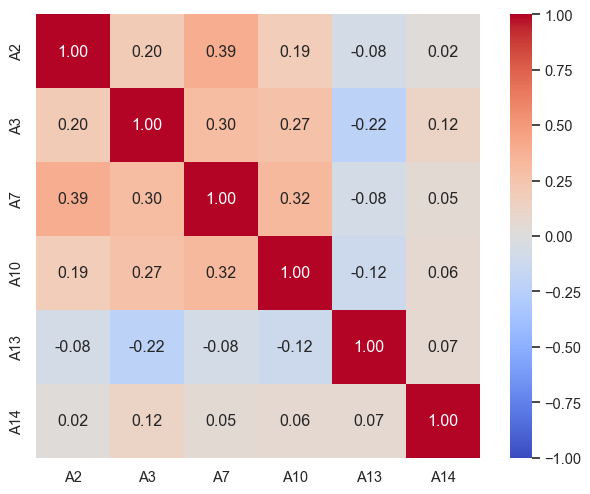

In [6]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[continuous_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center = 0, vmin=-1, vmax=1, fmt=".2f", square=True)
plt.show()

## KDE / Spine Plots

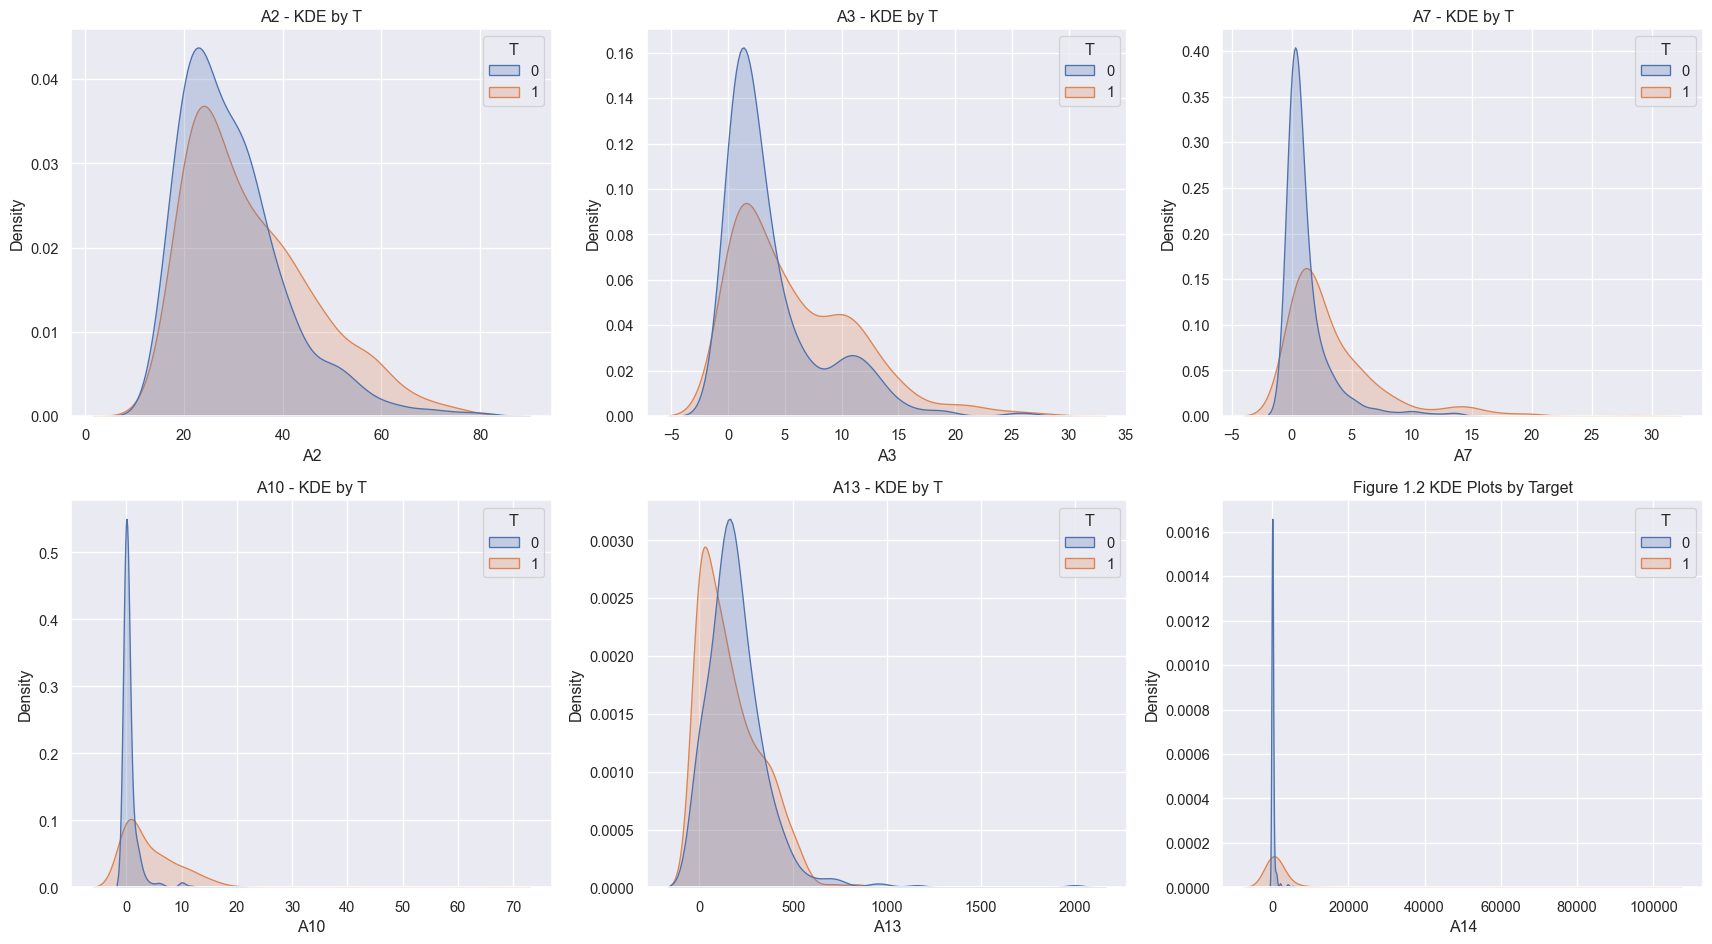

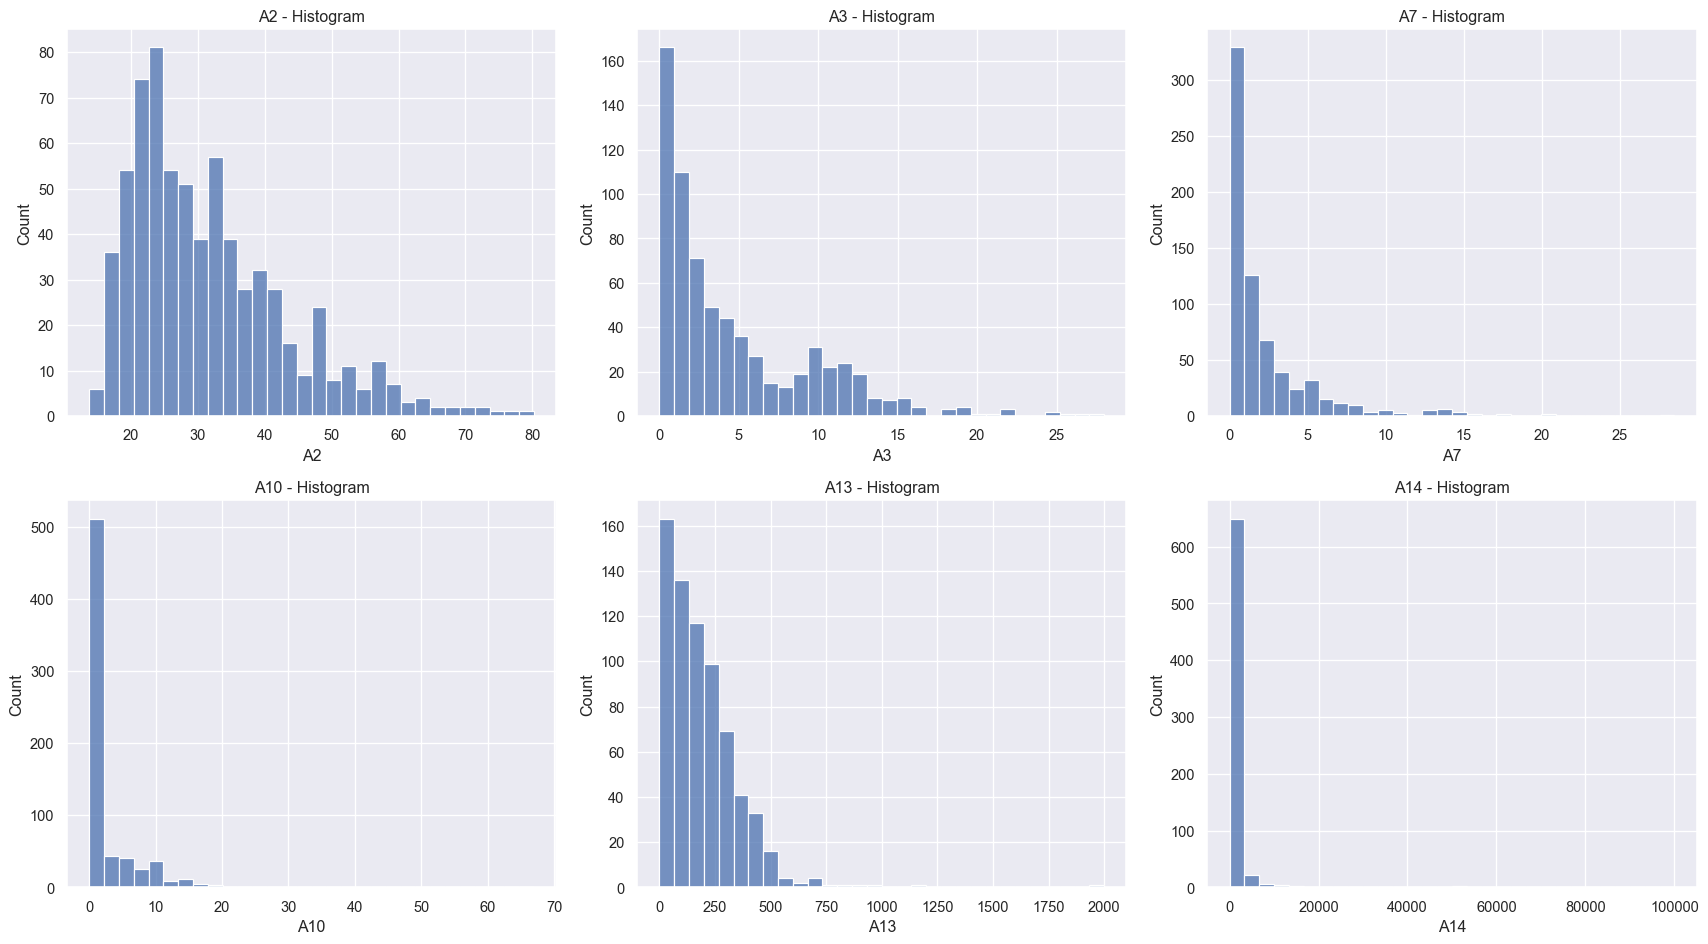

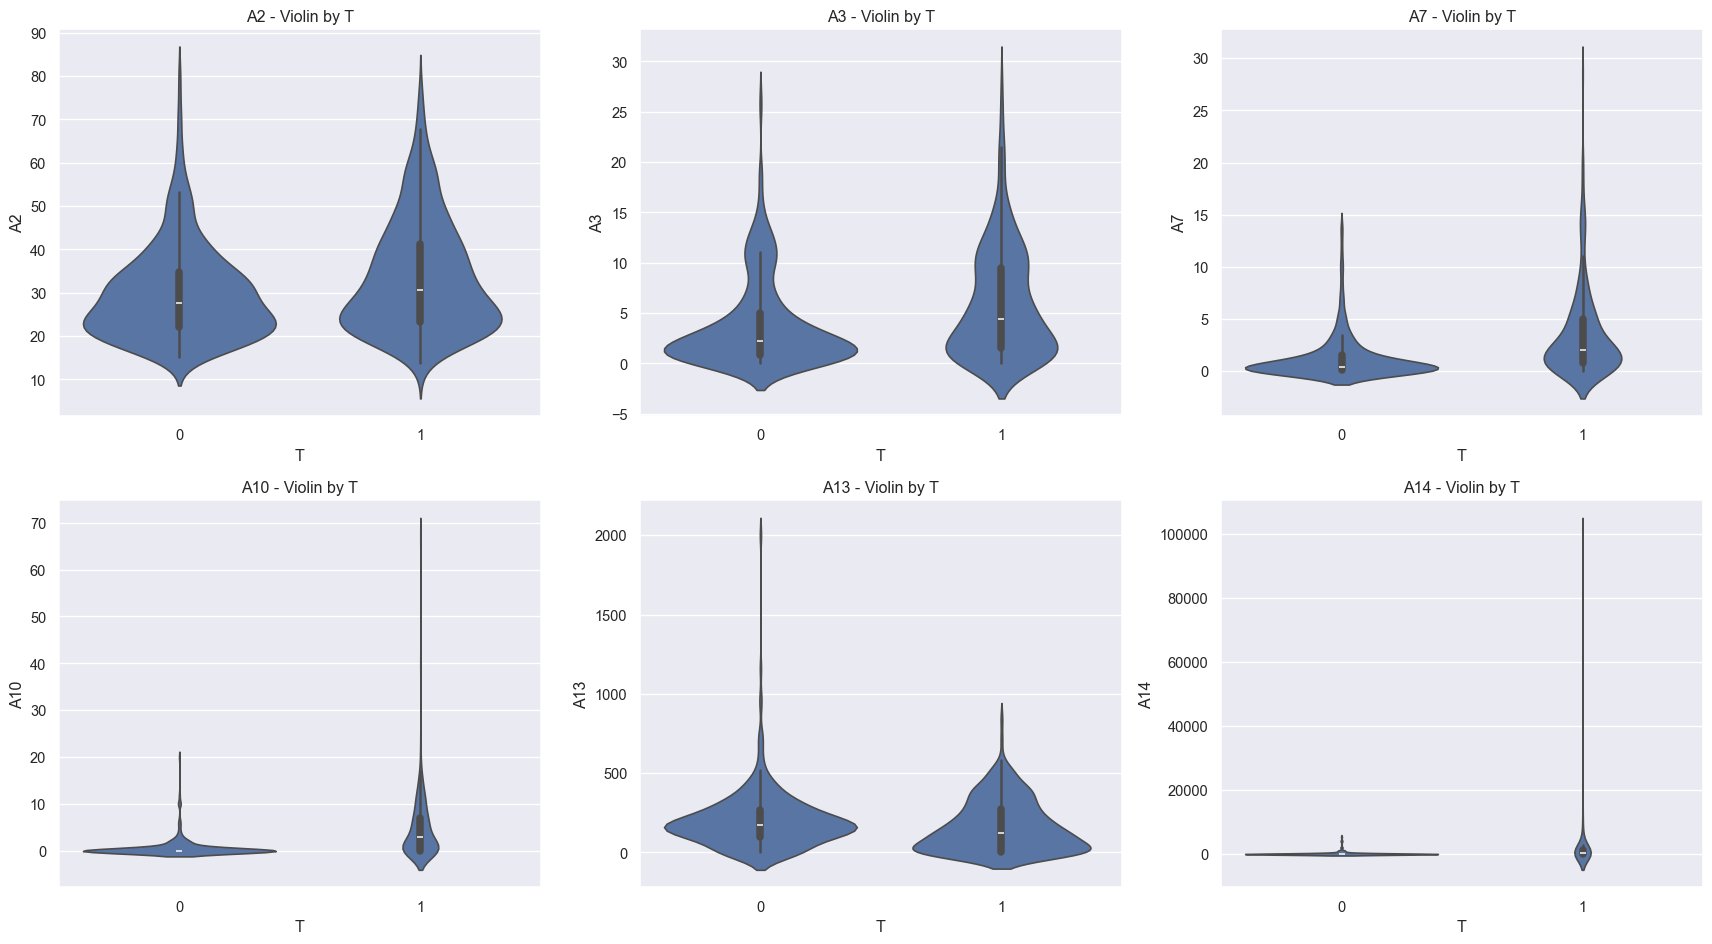

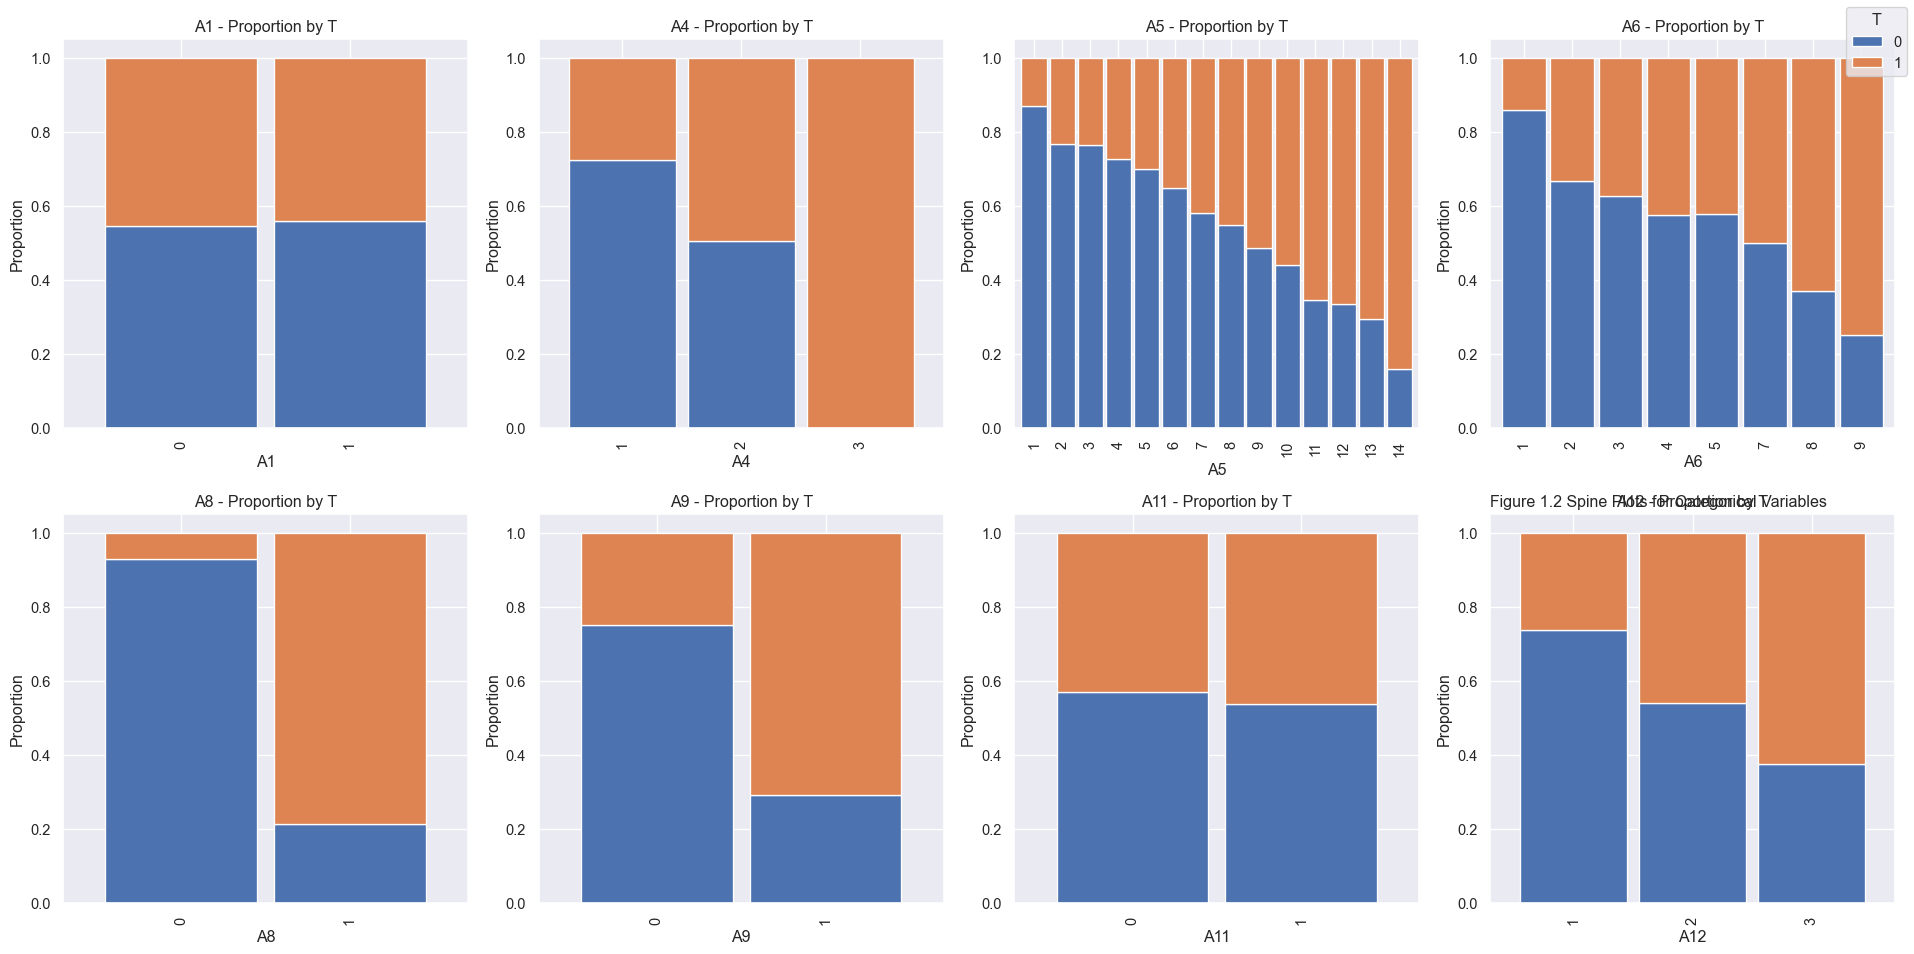

In [7]:
#gemini
#prompt: 
### Şunları çizdir:
## kde plot continuous değerler için, T target variableımızın kategorilere göre nasıl dağıldığı,
## continuous değerler için histogram T'ye kayıtsız,
## ayrıca bir de violin plot belki.
## catgeoric değerler için bir kategorinin bir level'i içinde T = 0 ve T = 1'in dağılımı, spine plot kullanabilirsin.
## pandas, sns, ve plt kullan, kod yorumlarını çok az tut 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Verinin 'df' adlı DataFrame'de olduğunu varsayıyoruz.
categorical_columns = ["A1", "A4", "A5", "A6", "A8", "A9", "A11", "A12"]
continuous_columns = ["A2", "A3", "A7", "A10", "A13", "A14"]
target = "T"

# 1. Continuous: KDE Plot (Target'a göre)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_columns):
    sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} - KDE by {target}')

plt.title("Figure 1.2 KDE Plots by Target")
plt.tight_layout()
plt.show()

# 2. Continuous: Histogram (Target'tan bağımsız)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_columns):
    sns.histplot(data=df, x=col, bins=30, ax=axes[i])
    axes[i].set_title(f'{col} - Histogram')

plt.tight_layout()
plt.show()

# 3. Continuous: Violin Plot (Target'a göre dağılım)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_columns):
    sns.violinplot(data=df, x=target, y=col, ax=axes[i])
    axes[i].set_title(f'{col} - Violin by {target}')

plt.tight_layout()
plt.show()

# 4. Categorical: Spine Plot Alternatifi (100% Stacked Bar)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    # Her kategori seviyesi için T=0 ve T=1 oranlarını hesapla
    cross_tab = pd.crosstab(df[col], df[target], normalize='index')
    
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], legend=False, width=0.9)
    axes[i].set_title(f'{col} - Proportion by {target}')
    axes[i].set_ylabel('Proportion')
    axes[i].margins(x=0) 

# Tek bir legend ekle
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=target, loc='upper right')
plt.title("Figure 1.2 Spine Plots for Categorical Variables", loc='left')
plt.tight_layout()
plt.show()

## Descriptives

In [8]:
df[continuous_columns].describe()

,A2,A3,A7,A10,A13,A14
count,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000
mean,31.568203,4.758725,2.223406,2.40000,184.014493,1018.385507
std,11.853273,4.978163,3.346513,4.86294,172.159274,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,1.000000
25%,22.670000,1.000000,0.165000,0.00000,80.000000,1.000000
50%,28.625000,2.750000,1.000000,0.00000,160.000000,6.000000
75%,37.707500,7.207500,2.625000,3.00000,272.000000,396.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100001.000000


In [9]:
df[continuous_columns].skew()

A2      1.155935
A3      1.488813
A7      2.891330
A10     5.152520
A13     2.749912
A14    13.140655
dtype: float64

In [10]:
df[continuous_columns].kurt()

A2       1.192059
A3       2.274022
A7      11.200192
A10     50.829431
A13     19.926698
A14    214.669972
dtype: float64

In [14]:
print(pd.crosstab(df["A8"], df["T"])) #since we have a quite strong feature, we are going to create a new baseline measure instead of NIR


T     0    1
A8          
0   306   23
1    77  284


We should benefit from some Box-Cox transformations

## Transformation

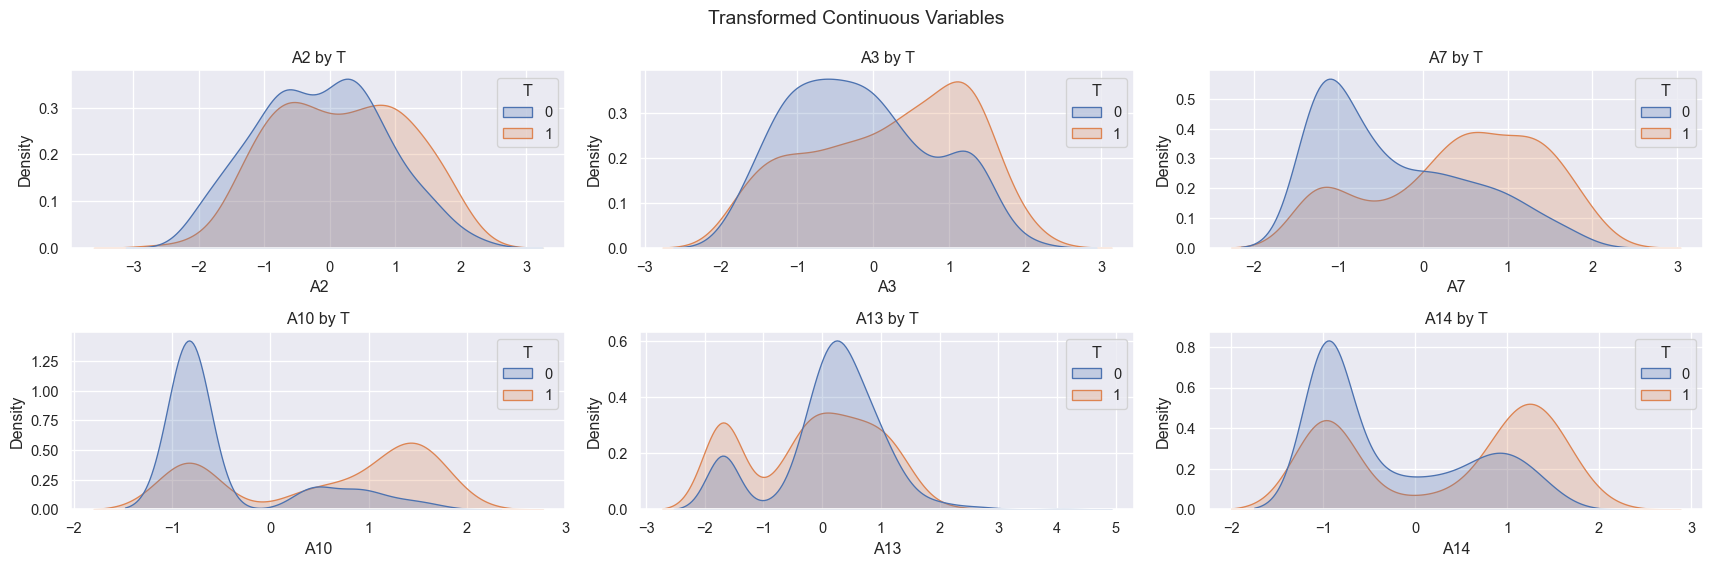

In [12]:
pt = PowerTransformer()
pt.fit(df[["A2","A3","A7","A10","A13","A14"]]) # all numeric features are skewed,
#before training models, lets see how this transformation will work out
candidates= pd.DataFrame(pt.transform(df[["A2","A3","A7","A10","A13","A14"]]), columns=["A2","A3","A7","A10","A13","A14"])
candidates["T"] = df["T"]
fig, axes = plt.subplots(2, 3, figsize=(18, 6))
fig.suptitle("Transformed Continuous Variables")
axes = axes.flatten()
for i, col in enumerate(continuous_columns):
    sns.kdeplot(data=candidates, x=col, hue=target, fill=True, common_norm=False, ax=axes[i])
    axes[i].set_title(f'{col} by {target}')
plt.tight_layout()
plt.show()


# Models - Baselines

## kNN

In [17]:

np.random.seed(SEED)

metrics_all_list = []
def fetch_metrics_to_list(X_train, X_test, y_train, y_test, model, model_name, save_to_list = "yes"):
    """a function appending metrics of best performer models from searches of test and train sets
    When a sklearn search object is passed, since the pipeline is naturally included no need to transform. """
    train_pred, test_pred = model.predict(X_train), model.predict(X_test)
    acc_test, acc_train  = accuracy_score(y_test, test_pred), accuracy_score(y_train, train_pred)
    prec_test, prec_train = precision_score(y_test, test_pred, pos_label=1, zero_division=0), precision_score(y_train, train_pred, pos_label=1, zero_division=0)
    rec_test, rec_train  = recall_score(y_test, test_pred, pos_label=1, zero_division=0), recall_score(y_train, train_pred, pos_label=1, zero_division=0)
    f1_test, f1_train   = f1_score(y_test, test_pred, pos_label=1, zero_division=0), f1_score(y_train, train_pred, pos_label=1, zero_division=0)
    roc_auc_test, roc_auc_train   = roc_auc_score(y_test, test_pred), roc_auc_score(y_train, train_pred)
    
    if hasattr(model, "predict_proba"):
        train_pred_proba = model.predict_proba(X_train)[:, 1]
        test_pred_proba  = model.predict_proba(X_test)[:, 1]
        logloss_test  = log_loss(y_test, test_pred_proba)
        logloss_train = log_loss(y_train, train_pred_proba)
   
    else:
        # Fallback for models that only output hard predictions
        logloss_test, logloss_train = None, None
    
    output = {"Model": model_name, 
              "Metrics": {"TestAccuracy": acc_test, "TrainAccuracy": acc_train,
              "TestPrecision": prec_test, "TrainPrecision": prec_train, 
              "TestRecall": rec_test, "TrainRecall": rec_train,
              "TestF1": f1_test, "TrainF1": f1_train, "TestLoss": logloss_test,"TrainLoss": logloss_train,
              "TestROC_AUC": roc_auc_test, "TrainROC_AUC": roc_auc_train}
              } 
    if save_to_list == "yes":
        metrics_all_list.append(output)
    return output

X, y = df[continuous_columns+categorical_columns].copy(), df["T"].copy()
y = y.astype(int)

onehot = OneHotEncoder(sparse_output=False)
onehot.set_output(transform="pandas")
X_cat = onehot.fit_transform(X[categorical_columns])
X_cat[continuous_columns] = X[continuous_columns]
X = X_cat

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1789, stratify=y) #this case we have the holdout test cases

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns) #standardize = True for standardizing automatically
    ], 
    remainder="passthrough"
)

knn_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", KNeighborsClassifier())
    )
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_grid = {"estimator__n_neighbors": list(range(1, 30)), "estimator__metric":["euclidean","manhattan"], "estimator__weights":["distance","uniform"]}

knn_gs     = GridSearchCV(knn_pipeline,
                           param_grid, cv=cv5,
                           scoring="f1", n_jobs=-1, refit=True)

print("||oo|| KNN Search ||oo||")
print("="*30)

knn_gs.fit(X_train, y_train)
best_knn = knn_gs.best_estimator_
best_k = knn_gs.best_params_["estimator__n_neighbors"]
cv_res_knn = pd.DataFrame(knn_gs.cv_results_)

print(f"Best k : {best_k}")
print(f"Best CV F1 : {knn_gs.best_score_:.4f}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_knn, "K-Neighbors") 
#since we have model = best_knn, the GridSearch output automatically uses preprocessors and pipelines defined above. 


||oo|| KNN Search ||oo||
Best k : 6
Best CV F1 : 0.8669


{'Model': 'K-Neighbors',
 'Metrics': {'TestAccuracy': 0.855072463768116,
  'TrainAccuracy': 1.0,
  'TestPrecision': 0.8596491228070176,
  'TrainPrecision': 1.0,
  'TestRecall': 0.8032786885245902,
  'TrainRecall': 1.0,
  'TestF1': 0.8305084745762712,
  'TrainF1': 1.0,
  'TestLoss': 1.066899820251946,
  'TrainLoss': 2.220446049250313e-16,
  'TestROC_AUC': 0.8496912923142431,
  'TrainROC_AUC': 1.0}}

Text(0.5, 1.0, 'KNN Confusion Matrix')

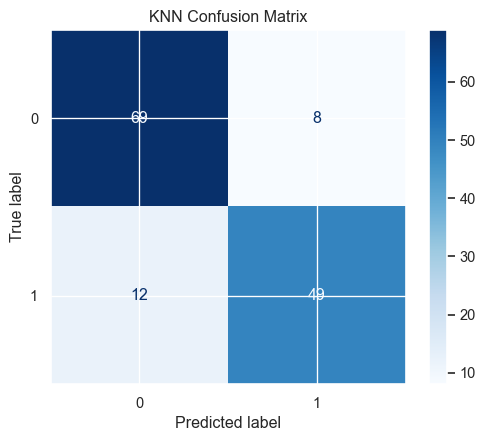

In [18]:
ConfusionMatrixDisplay.from_estimator(best_knn, X_test, y_test, cmap="Blues")
plt.title("KNN Confusion Matrix")

## SVMs

### E: Deciding on Kernel Functions


Deciding the kernel functions: 
- Which features are more important -> Run kind of MI detector, see the sklearn
- - See pairwise relationships between them, how do they seperate? 
- - Hypothesize Two relationships
- - In gridsearch, look for all kernels


In [19]:
from sklearn.feature_selection import mutual_info_classif
df_mi = df.copy()
pt = PowerTransformer()
df_mi[["A2","A3","A7","A10","A13","A14"]] = pt.fit_transform(df_mi[["A2","A3","A7","A10","A13","A14"]]) # all numeric features are skewed,

X_mi = preprocessor.fit_transform(X)
y_mi = y.copy()
features = preprocessor.get_feature_names_out()
is_discrete = [name.startswith('cat') for name in features]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=is_discrete, random_state=SEED)
mi_series = pd.Series(mi_scores, index=preprocessor.get_feature_names_out()).sort_values(ascending=False)

print("MI Values")
mi_series.head(n=10)

#

MI Values


remainder__A8_0    0.321611
remainder__A8_1    0.295334
num__A10           0.164730
remainder__A9_1    0.124921
num__A14           0.102978
remainder__A9_0    0.084692
num__A7            0.080701
num__A13           0.059857
remainder__A6_9    0.050528
remainder__A1_1    0.035226
dtype: float64

Most informative features are A8, A10 and A14

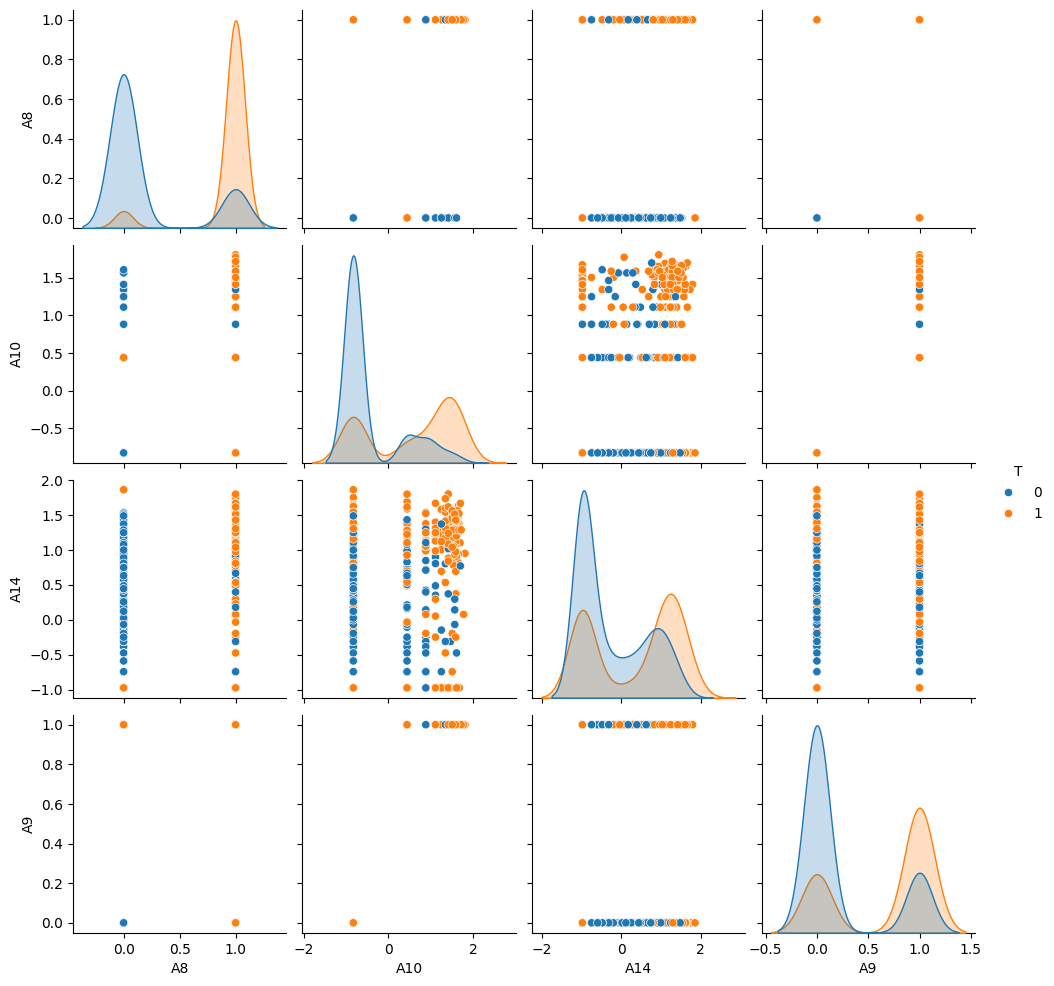

In [ ]:
df_mi_plot = df_mi[["A8","A10","A14","A9","T"]]
sns.pairplot(df_mi_plot, hue="T", )
plt.show()

### Continuing SVMs

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y) #this case we have the holdout test cases

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns) #standardize = True for standardizing automatically
    ], 
    remainder="passthrough"
)
svm_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", SVC(random_state=SEED))
    )
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_grid = [
    {
        'estimator__kernel': ['linear'],
        'estimator__C': [0.001, 0.01, 0.1, 1, 10]
    },
    {
        'estimator__kernel': ['rbf'],
        'estimator__C': [0.001, 0.01, 0.1, 1, 10],
        'estimator__gamma': ['scale', 'auto', 0.01, 0.1, 1, 10]
    },
    {
        'estimator__kernel': ['poly'],
        'estimator__C': [0.1, 1, 10],
        'estimator__degree': [2, 3],
        'estimator__gamma': ['scale',0.01, 0.1, 1, 10],
        'estimator__coef0': [-1, 0, 1]
    },
    {
        'estimator__kernel': ['sigmoid'],
        'estimator__C': [0.001, 0.01, 0.1, 1, 10],
        'estimator__gamma': ['scale',0.01, 0.1, 1, 10],
        'estimator__coef0': [-1, 0, 1]
    }
] 
svm_gs = GridSearchCV(svm_pipeline,
                    param_grid, cv=cv5,
                    scoring="f1", n_jobs=-1,
                    refit=True)

print("||oo|| SVM Search ||oo||")
print("="*30)

svm_gs.fit(X_train, y_train)
best_svm = svm_gs.best_estimator_
y_pred = best_svm.predict(X_test)

print(f"Best Score SVM: {svm_gs.best_score_:.4f}")
print(f"Best Params SVM:\n{svm_gs.best_params_}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_svm, "SVM")
cv_res_svm = svm_gs.cv_results_

||oo|| SVM Search ||oo||
Best Score SVM: 0.8610
Best Params SVM:
{'estimator__C': 1, 'estimator__coef0': 0, 'estimator__degree': 3, 'estimator__gamma': 0.1, 'estimator__kernel': 'poly'}


In [ ]:
pd.DataFrame(cv_res_svm).sort_values(by="rank_test_score")

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__C,param_estimator__kernel,param_estimator__gamma,param_estimator__coef0,param_estimator__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
82,0.045370,0.002296,0.011375,0.000761,1.000,poly,0.1,0.0,3.0,"{'estimator__C': 1, 'estimator__coef0': 0, 'es...",0.824742,0.903226,0.863158,0.868687,0.845361,0.861035,0.026100,1
80,0.046635,0.002606,0.011678,0.000919,1.000,poly,scale,0.0,3.0,"{'estimator__C': 1, 'estimator__coef0': 0, 'es...",0.842105,0.893617,0.863158,0.846154,0.836735,0.856354,0.020624,2
2,0.054736,0.007939,0.014469,0.002439,0.100,linear,NaN,NaN,NaN,"{'estimator__C': 0.1, 'estimator__kernel': 'li...",0.893204,0.880734,0.838095,0.810811,0.849057,0.854380,0.029643,3
25,0.069557,0.024686,0.018770,0.006034,1.000,rbf,0.01,NaN,NaN,"{'estimator__C': 1, 'estimator__gamma': 0.01, ...",0.893204,0.880734,0.838095,0.810811,0.849057,0.854380,0.029643,3
86,0.043987,0.002287,0.011473,0.000910,1.000,poly,0.01,1.0,2.0,"{'estimator__C': 1, 'estimator__coef0': 1, 'es...",0.893204,0.880734,0.838095,0.810811,0.849057,0.854380,0.029643,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.051545,0.002557,0.015791,0.003258,0.001,sigmoid,10,1.0,NaN,"{'estimator__C': 0.001, 'estimator__coef0': 1,...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159
137,0.051190,0.002901,0.014363,0.000379,0.001,sigmoid,0.1,1.0,NaN,"{'estimator__C': 0.001, 'estimator__coef0': 1,...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159
136,0.054121,0.003047,0.014046,0.001089,0.001,sigmoid,0.01,1.0,NaN,"{'estimator__C': 0.001, 'estimator__coef0': 1,...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159
134,0.050498,0.002461,0.012325,0.000378,0.001,sigmoid,10,0.0,NaN,"{'estimator__C': 0.001, 'estimator__coef0': 0,...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159


In [ ]:
polynomial_svm = SVC(C=1,kernel="poly",degree=3, gamma=0.1, coef0=0)
linear_svm = SVC(C=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=SEED, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True,random_state=SEED)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns) #standardize = True for standardizing automatically
    ], 
    remainder="passthrough"
)

poly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm', polynomial_svm)
])

linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('svm', linear_svm)
])

cv_results_poly = cross_val_score(poly_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
cv_results_linear = cross_val_score(linear_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Polynomial SVM CV accuracy: {cv_results_poly.mean():.4f} ± {cv_results_poly.std():.4f}")
print(f"Linear SVM CV accuracy: {cv_results_linear.mean():.4f} ± {cv_results_linear.std():.4f}")

poly_pipeline.fit(X_train, y_train)
linear_pipeline.fit(X_train, y_train)

fetch_metrics_to_list(X_train, X_test, y_train, y_test, poly_pipeline, "Polynomial SVM")
fetch_metrics_to_list(X_train, X_test, y_train, y_test, linear_pipeline, "Linear SVM")


Polynomial SVM CV accuracy: 0.8608 ± 0.0346
Linear SVM CV accuracy: 0.8375 ± 0.0217


{'Model': 'Linear SVM',
 'Metrics': {'TestAccuracy': 0.8208092485549133,
  'TrainAccuracy': 0.8626692456479691,
  'TestPrecision': 0.896551724137931,
  'TrainPrecision': 0.9076923076923077,
  'TestRecall': 0.6753246753246753,
  'TrainRecall': 0.7695652173913043,
  'TestF1': 0.7703703703703704,
  'TrainF1': 0.8329411764705882,
  'TestLoss': None,
  'TrainLoss': None,
  'TestROC_AUC': 0.8064123376623377,
  'TrainROC_AUC': 0.8534237236782306}}

# Ensemble Methods
- Write the code for tuning and fitting, 
- Extract data

## RandomForest

In [30]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y) #this case we have the holdout test cases

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns) #standardize = True for standardizing automatically
    ], 
    remainder="passthrough"
)

rf_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", RandomForestClassifier(random_state=SEED, oob_score=True))
    )
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

param_dist = {
    "estimator__n_estimators": randint(40, 400), 
    "estimator__max_depth": [5, 10, 15, 20, 25], 
    "estimator__min_samples_split": randint(2, 25), 
    "estimator__min_samples_leaf": randint(1, 15),
    "estimator__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "estimator__max_samples": [0.6, 0.7, 0.8, 0.9]
}

rf_randomsearch = RandomizedSearchCV(estimator=rf_pipeline,
                                     cv=cv5,
                                     scoring="f1",
                                     param_distributions=param_dist,
                                     n_jobs=-1, n_iter=100
                                     )
rf_randomsearch.fit(X_train, y_train)

rf_random_best = rf_randomsearch.best_estimator_
cv_res_rsearch_rforest = rf_randomsearch.cv_results_

print("Random Search for Random Forest")
print(f"Best Parameters:{rf_randomsearch.best_params_}")

bp = rf_randomsearch.best_params_
param_grid = {
    "estimator__n_estimators": [max(40, bp["estimator__n_estimators"]-50), 
                                bp["estimator__n_estimators"], 
                                bp["estimator__n_estimators"]+40],
    "estimator__max_depth": [max(bp["estimator__max_depth"]-5, 3), 
                             bp["estimator__max_depth"], 
                             bp["estimator__max_depth"]+5], 
    "estimator__min_samples_split": [max(bp["estimator__min_samples_split"]-5, 1),
                                     bp["estimator__min_samples_split"],
                                     bp["estimator__min_samples_split"]+5], 
    "estimator__min_samples_leaf": [max(bp["estimator__min_samples_leaf"]-3, 1),
                                    bp["estimator__min_samples_leaf"],
                                    bp["estimator__min_samples_leaf"]+3],
    "estimator__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
    "estimator__max_samples": [max(bp["estimator__max_samples"]-0.1, 0.1),
                               bp["estimator__max_samples"],
                               bp["estimator__max_samples"]+0.1]
}

rf_gs = GridSearchCV(rf_pipeline,
                    param_grid, cv=cv5,
                    scoring="f1", n_jobs=-1,
                    refit=True)

print("||oo|| Random Forest Search ||oo||")
print("="*30)

rf_gs.fit(X_train, y_train)
best_rf = rf_gs.best_estimator_
y_pred = best_rf.predict(X_test)
best_params_rf = rf_gs.best_params_
print(f"Best Score Random Forest: {rf_gs.best_score_:.4f}")
print(f"Best Params Random Forest:\n{best_params_rf}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_rf, "RandomForest")
cv_res_rf = rf_gs.cv_results_


Random Search for Random Forest
Best Parameters:{'estimator__max_depth': 20, 'estimator__max_features': 0.5, 'estimator__max_samples': 0.8, 'estimator__min_samples_leaf': 5, 'estimator__min_samples_split': 11, 'estimator__n_estimators': 184}
||oo|| Random Forest Search ||oo||
Best Score Random Forest: 0.8635
Best Params Random Forest:
{'estimator__max_depth': 15, 'estimator__max_features': 'log2', 'estimator__max_samples': 0.8, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 6, 'estimator__n_estimators': 184}


### SHAP

In [31]:

best_rf_model = best_rf["estimator"]
preprocessor = best_rf["preprocessor"] # got help from gemini about fitting the preprocessor
preprocessor.set_output(transform="pandas")

X_test_transformed = preprocessor.transform(X_test)

explainer = shap.TreeExplainer(best_rf_model)
shap_explanation = explainer(X_test_transformed)

C:\Users\elito\AppData\Local\Temp\ipykernel_27360\1908311797.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_explanation_class_1, X_test_transformed, max_display=10)


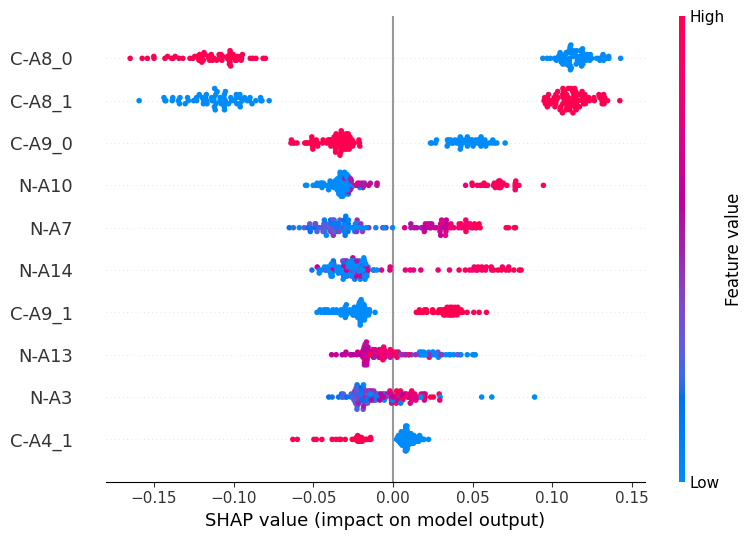

Text(0.5, 1.0, 'SHAP Values for T = 1')

In [32]:
shap_explanation_class_1 = shap_explanation[:, :, 1]

clean_names = [name.replace("num__", "N-").replace("remainder__", "C-") 
               for name in shap_explanation_class_1.feature_names] #gemini
shap_explanation_class_1.feature_names = clean_names

shap.summary_plot(shap_explanation_class_1, X_test_transformed, max_display=10)
plt.title("SHAP Values for T = 1")

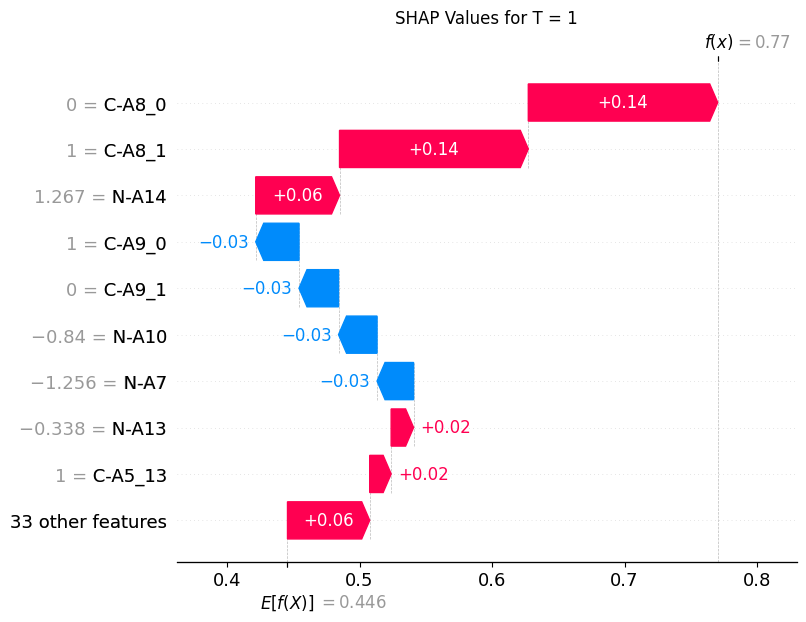

In [33]:
sns.reset_orig()
shap.plots.waterfall(shap_explanation_class_1[5])

### Feature Importance


In [34]:

fi = best_rf_model.feature_importances_
feature_names = best_rf['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame(fi, feature_names, columns=["Importance"])

In [35]:
feature_importance_df.sort_values(by="Importance", ascending=False)

,Importance
remainder__A8_0,0.196424
remainder__A8_1,0.193049
num__A10,0.078771
num__A7,0.073824
num__A14,0.066922
remainder__A9_0,0.063748
num__A3,0.052053
num__A2,0.044510
num__A13,0.043220
remainder__A9_1,0.043167


In [ ]:
top_10_features = feature_importance_df.sort_values(by="Importance", ascending=True).tail(10)

# Initialize a larger figure
plt.figure(figsize=(5, 5), dpi = 96)

# Plot horizontal bars
top_10_features.plot(
    kind="barh", 
    y="Importance", 
    color="steelblue", 
    legend=False, 
    ax=plt.gca()
)

# Add clear labels and title
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)

# Add a vertical grid for easier value reading
plt.grid(axis="x", linestyle="--", alpha=0.6)

# Ensure everything fits within the frame
plt.tight_layout()
plt.show()

## XGBoost

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y) 

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns) #standardize = True for standardizing automatically
    ], 
    remainder="passthrough"
)

xgb_pipeline = Pipeline(steps =
    (
    ("preprocessor", preprocessor),
    ("estimator", XGBClassifier(eval_metric="logloss", use_label_encoder=False, random_state=SEED, n_jobs=-1))
    )
)

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

param_dist = {
    "estimator__n_estimators": randint(40, 400),
    "estimator__learning_rate": uniform(loc=0, scale=1),
    "estimator__max_depth": [3, 5, 7, 9],
    "estimator__min_child_weight": [1, 5, 10, 15],
    "estimator__gamma": [0.0, 1.0, 2.5, 5.0],
    
    
    "estimator__subsample": [0.5, 0.75, 1.0],
    "estimator__colsample_bytree": [0.5, 0.75, 1.0],
    "estimator__colsample_bylevel": [0.5, 0.75, 1.0],
    
    "estimator__reg_alpha": loguniform(1e-5, 10.0),
    "estimator__reg_lambda": loguniform(1e-5, 10.0)
    
}

xgb_randomsearch = RandomizedSearchCV(estimator=xgb_pipeline,
                                      cv=cv3,
                                      param_distributions=param_dist, 
                                      scoring="f1", n_jobs=-1, n_iter=300)
xgb_randomsearch.fit(X_train, y_train)

print("Random Search for XGBoost")
best_params_xgb = xgb_randomsearch.best_params_
print(f"Best Parameters:{best_params_xgb}")

best_xgb = xgb_randomsearch.best_estimator_

print(f"Best Score XGBoost: {xgb_randomsearch.best_score_:.4f}")
print(f"Best Params XGBoost:\n{xgb_randomsearch.best_params_}")

fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_xgb, "XGBoost")

Random Search for XGBoost
Best Parameters:{'estimator__colsample_bylevel': 0.75, 'estimator__colsample_bytree': 0.75, 'estimator__gamma': 2.5, 'estimator__learning_rate': np.float64(0.7633162928108994), 'estimator__max_depth': 3, 'estimator__min_child_weight': 10, 'estimator__n_estimators': 286, 'estimator__reg_alpha': np.float64(0.14243413552566292), 'estimator__reg_lambda': np.float64(0.000692063224992315), 'estimator__subsample': 0.75}
Best Score XGBoost: 0.8643
Best Params XGBoost:
{'estimator__colsample_bylevel': 0.75, 'estimator__colsample_bytree': 0.75, 'estimator__gamma': 2.5, 'estimator__learning_rate': np.float64(0.7633162928108994), 'estimator__max_depth': 3, 'estimator__min_child_weight': 10, 'estimator__n_estimators': 286, 'estimator__reg_alpha': np.float64(0.14243413552566292), 'estimator__reg_lambda': np.float64(0.000692063224992315), 'estimator__subsample': 0.75}


c:\Users\elito\miniconda3\envs\noobData\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:01:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'Model': 'XGBoost',
 'Metrics': {'TestAccuracy': 0.8768115942028986,
  'TrainAccuracy': 0.9148550724637681,
  'TestPrecision': 0.8666666666666667,
  'TrainPrecision': 0.9094650205761317,
  'TestRecall': 0.8524590163934426,
  'TrainRecall': 0.8983739837398373,
  'TestF1': 0.859504132231405,
  'TrainF1': 0.9038854805725971,
  'TestLoss': 0.32521173633324596,
  'TrainLoss': 0.23605482468152036,
  'TestROC_AUC': 0.8742814562486693,
  'TrainROC_AUC': 0.9132392794516181}}

In [39]:
res_cv_xgb = pd.DataFrame(xgb_randomsearch.cv_results_)

## Comparison of Bias & Variance Profiles

In [40]:
rng = np.random.default_rng(SEED)
n = 30
seeds = [rng.integers(1, 1.e6, 5) for _ in range(n)]
for seed in seeds:
    print(seed)

[908515 858687 652753 425704 479103]
[637270 641687 471079 670784 930704]
[  8043  78456 819543 809069 630372]
[ 20823  71790 357658 913926 867984]
[ 74264 888193 957279 567207 508406]
[463495 448457 190390 256917 871182]
[812253 670654 150601 707218 727514]
[846817 989707 677960  99142  31138]
[361165 690600  59194 667312 389742]
[ 52366 233406 762130 505641 520219]
[164581 878833 802476 583691 844062]
[816061 529967 776174  75752 500122]
[212914 690403 162608 748365 115851]
[ 17199 619868 100564 679485 707726]
[843610 310594 356464 970760 749909]
[ 30567 974430 710171 533051 492363]
[341881 307129 201899   5758 271548]
[459935 995148 428653 605470 345451]
[668487 238141 470206 364221 843390]
[ 60158 235343 988926 254735 227792]
[454223  82044 883499 927966 193096]
[833171 717859 436584 548131 232727]
[737479 277316 957178 206657 754162]
[463804 438399  86529 761656 220640]
[773064 654654 951489 623046 626992]
[129576 384481 624995 195461 275851]
[572072 844897 802555 691731 609644]
[

In [41]:
# the bias profile: of 15 cross validatied models, pick training loss as sample for both rf and xgb
# the variance profile: run 15 cross validated models on test set as sample for rf and xgb variance

best_params_xgb = xgb_randomsearch.best_params_
best_params_rf = rf_gs.best_params_
best_params_xgb_cleaned = {k.replace("estimator__", ""): v for k, v in best_params_xgb.items()}
best_params_rf_cleaned = {k.replace("estimator__", ""): v for k, v in best_params_rf.items()}

X_train, X_holdout, y_train, y_holdout = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

models = []

# models: best_rf, best_xg
def safe_index(data, indices):
    if hasattr(data, "iloc"):
        return data.iloc[indices]
    return data[indices]


# Stratified K-Fold over the training data
n_splits = 5
n_repeats = 6

rskf = RepeatedStratifiedKFold(
    n_splits=n_splits,
    n_repeats=n_repeats,
    random_state=SEED   # this controls the randomness of the whole repetition
)


for i, (train_idx, val_idx) in enumerate(rskf.split(X_train, y_train)):

    # Get fold-specific data
    X_train_fold = safe_index(X_train, train_idx)
    X_test_fold = safe_index(X_train, val_idx)
    y_train_fold = safe_index(y_train, train_idx)
    y_test_fold = safe_index(y_train, val_idx)

    # Use seeds for model randomness
    rs1, rs2, rs3, rs4, rs5 = seeds[i]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", PowerTransformer(standardize=True), continuous_columns)
        ],
        remainder="passthrough"
    )

    xgb_optimized = XGBClassifier(
        **best_params_xgb_cleaned,
        random_state=rs2
    )

    rf_optimized = RandomForestClassifier(
        **best_params_rf_cleaned,
        random_state=rs3
    )

    xgb_base = XGBClassifier(
        random_state=rs4
    )

    rf_base = RandomForestClassifier(
        random_state=rs5
    )

    X_train_fold_t = preprocessor.fit_transform(X_train_fold)
    X_test_fold_t = preprocessor.transform(X_test_fold)

    xgb_optimized.fit(X_train_fold_t, y_train_fold)
    rf_optimized.fit(X_train_fold_t, y_train_fold)
    xgb_base.fit(X_train_fold_t, y_train_fold)
    rf_base.fit(X_train_fold_t, y_train_fold)

    models.append({
        "preprocessor": preprocessor,
        "models": [xgb_optimized, xgb_base, rf_optimized, rf_base]
    })

    names_models = {
        "Tuned_XGB": xgb_optimized,
        "Baseline_XGB": xgb_base,
        "Tuned_RF": rf_optimized,
        "Baseline_RF": rf_base
    }

    for model_name, model in names_models.items():
        fetch_metrics_to_list(
            X_train_fold_t,
            X_test_fold_t,
            y_train_fold,
            y_test_fold,
            model,
            model_name=f"__CV_{model_name}_{i+1}"
        )

    print(f"Fold {i+1}/{n} done.")

    time.sleep(2)
    clear_output(wait=False)


    

In [ ]:
preprocessor = ColumnTransformer( 
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns) 
    ], 
    remainder="passthrough"
)
X_train_t = preprocessor.fit_transform(X_train)
X_holdout_t = preprocessor.transform(X_holdout)
for i in range(len(models)):
    model_list = models[i]["models"]
    names_models = {"Tuned_XGB": 0, "Baseline_XGB": 1,
                "Tuned_RF": 2, "Baseline_RF": 3}
    for j, (model_name, model) in enumerate(names_models.items()): 
        fetch_metrics_to_list(X_train_t, X_holdout_t, y_train, y_holdout, model_list[model], model_name=f"__TEST_{model_name}_{i+1}")

In [43]:
ep_dict = [{'Model': item['Model'], **item['Metrics']} for item in metrics_all_list]
ep = pd.DataFrame(ep_dict)
ep['Tuning'] = np.where(ep['Model'].str.contains('Tuned'), 'Tuned', 'Base')
ep['Bag/Boost'] = np.where(ep['Model'].str.contains('XGB'), 'Boosting', 'Bagging')
ep_cv = ep.iloc[np.where(ep['Model'].str.contains('__CV_'))]
ep_cv
ep_test = ep.iloc[np.where(ep['Model'].str.contains('__TEST_'))]

In [44]:
evaluate_profiles_df = pd.concat([ep_test, ep_cv])
evaluate_profiles_df = evaluate_profiles_df.reset_index(drop=True)
evaluate_profiles_df["Holdout/Validation"] = np.where(evaluate_profiles_df['Model'].str.contains('__CV_'), 'Val', 'Holdout')
print(evaluate_profiles_df.columns)
evaluate_profiles_df


Index(['Model', 'TestAccuracy', 'TrainAccuracy', 'TestPrecision',
       'TrainPrecision', 'TestRecall', 'TrainRecall', 'TestF1', 'TrainF1',
       'TestLoss', 'TrainLoss', 'TestROC_AUC', 'TrainROC_AUC', 'Tuning',
       'Bag/Boost', 'Holdout/Validation'],
      dtype='object')


,Model,TestAccuracy,TrainAccuracy,TestPrecision,TrainPrecision,TestRecall,TrainRecall,TestF1,TrainF1,TestLoss,TrainLoss,TestROC_AUC,TrainROC_AUC,Tuning,Bag/Boost,Holdout/Validation
0,__TEST_Tuned_XGB_1,0.855072,0.893116,0.815385,0.875502,0.868852,0.886179,0.841270,0.880808,0.342633,0.285379,0.856504,0.892436,Tuned,Boosting,Holdout
1,__TEST_Baseline_XGB_1,0.855072,0.972826,0.859649,0.971429,0.803279,0.967480,0.830508,0.969450,0.359821,0.111433,0.849691,0.972302,Base,Boosting,Holdout
2,__TEST_Tuned_RF_1,0.862319,0.923913,0.850000,0.921488,0.836066,0.906504,0.842975,0.913934,0.338447,0.237085,0.859591,0.922206,Tuned,Bagging,Holdout
3,__TEST_Baseline_RF_1,0.855072,0.974638,0.836066,0.979339,0.836066,0.963415,0.836066,0.971311,0.328148,0.193588,0.853098,0.973537,Base,Bagging,Holdout
4,__TEST_Tuned_XGB_2,0.855072,0.893116,0.836066,0.875502,0.836066,0.886179,0.836066,0.880808,0.355467,0.291439,0.853098,0.892436,Tuned,Boosting,Holdout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,__CV_Baseline_RF_29,0.854545,1.000000,0.823529,1.000000,0.857143,1.000000,0.840000,1.000000,0.361464,0.083191,0.854801,1.000000,Base,Bagging,Val
236,__CV_Tuned_XGB_30,0.809091,0.902715,0.791667,0.888889,0.775510,0.893401,0.783505,0.891139,0.445513,0.251308,0.805788,0.901803,Tuned,Boosting,Val
237,__CV_Baseline_XGB_30,0.836364,1.000000,0.860465,1.000000,0.755102,1.000000,0.804348,1.000000,0.503373,0.018731,0.828371,1.000000,Base,Boosting,Val
238,__CV_Tuned_RF_30,0.845455,0.934389,0.847826,0.924242,0.795918,0.928934,0.821053,0.926582,0.387028,0.202156,0.840582,0.933855,Tuned,Bagging,Val


In [45]:
#Empirical Proxies: 
# Bias ->  Training Loss, 1 - Training Accuracy
# Variance -> Generalization Gap i.e Training Loss vs. Validation Loss, that is TestLoss - TrainLoss
# Variance 2nd Proxy -> Distribution of validation and holdout scores through CV steps.
evaluate_profiles_df['Gap_Acc'] = evaluate_profiles_df['TrainAccuracy'] - evaluate_profiles_df['TestAccuracy']
evaluate_profiles_df['Gap_Loss'] = evaluate_profiles_df['TestLoss'] - evaluate_profiles_df['TrainLoss']

evaluate_profiles_df['Bias_Acc'] = evaluate_profiles_df['TrainLoss']
evaluate_profiles_df['Bias_Loss'] = 1 - evaluate_profiles_df['TrainAccuracy']

bias_variance_summary = evaluate_profiles_df.iloc[(evaluate_profiles_df["Holdout/Validation"]=="Holdout").index].groupby(['Bag/Boost', 'Tuning']).agg({
    'Bias_Acc': 'mean',
    'Bias_Loss': 'mean',
    'Gap_Acc': 'mean',
    'Gap_Loss': 'mean',
    'TestAccuracy': 'mean'
}).reset_index()

bias_variance_summary = bias_variance_summary.sort_values(by='TestAccuracy', ascending=False)

print(bias_variance_summary.to_string(index=False))

Bag/Boost Tuning  Bias_Acc  Bias_Loss  Gap_Acc  Gap_Loss  TestAccuracy
  Bagging   Base  0.124287   0.014289 0.115782  0.271231      0.869929
  Bagging  Tuned  0.225476   0.070214 0.063421  0.111668      0.866365
 Boosting   Base  0.071371   0.017482 0.118010  0.342795      0.864508
 Boosting  Tuned  0.273691   0.105585 0.041288  0.090231      0.853127


In [46]:
output_dist_analysis = evaluate_profiles_df[evaluate_profiles_df["Holdout/Validation"]=="Holdout"] #check only the holdout set
check_scores = ["TestF1","TestAccuracy","TestROC_AUC","TestLoss"] #fetch only these scores
output_dist_analysis = output_dist_analysis[check_scores+["Bag/Boost"]] #melt tuned vs base
agg_table = output_dist_analysis.groupby(by="Bag/Boost").agg({
    "TestF1": ["mean","var","std"],
    "TestAccuracy": ["mean","var","std"],
    "TestROC_AUC": ["mean","var","std"],
    "TestLoss": ["mean","var","std"]
}).stack(level=1)
agg_table = agg_table.round(4)
agg_table

C:\Users\elito\AppData\Local\Temp\ipykernel_27360\1894494395.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  }).stack(level=1)


TestF1  TestAccuracy  TestROC_AUC  TestLoss
Bag/Boost                                                  
Bagging   mean  0.8505        0.8674       0.8659    0.3427
          var   0.0003        0.0002       0.0002    0.0016
          std   0.0171        0.0152       0.0153    0.0401
Boosting  mean  0.8371        0.8564       0.8541    0.3769
          var   0.0004        0.0003       0.0003    0.0011
          std   0.0193        0.0177       0.0173    0.0330

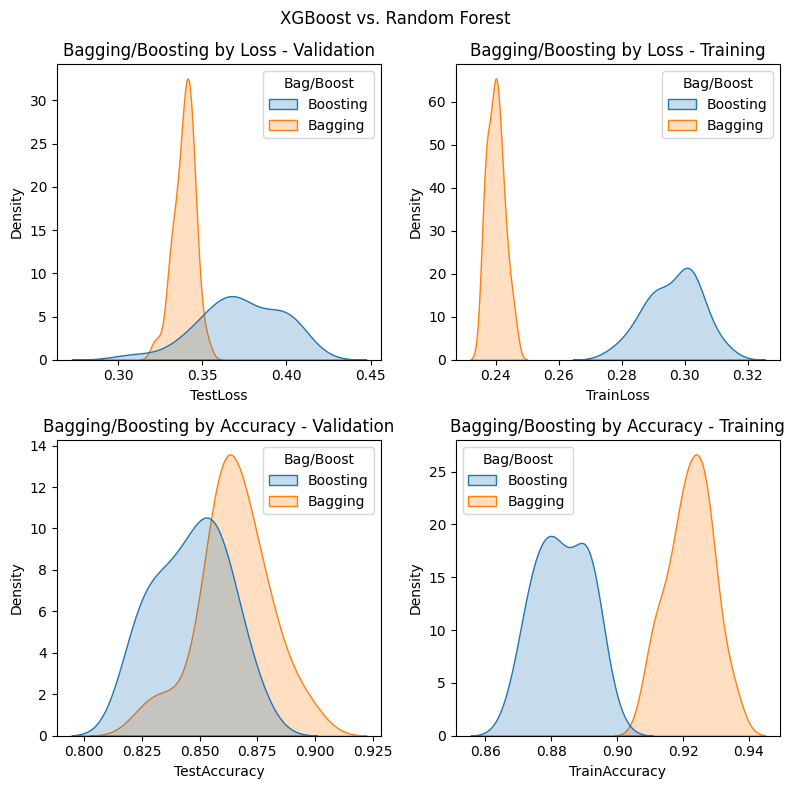

In [ ]:
target_metrics = ["TestLoss", "TrainLoss","TestAccuracy","TrainAccuracy"] 
colnames = ["Loss - Holdout", "Loss - Training", "Accuracy - Holdout", "Accuracy - Training"]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("XGBoost vs. Random Forest")
axes = axes.flatten()
for i, col in enumerate(target_metrics):
    sns.kdeplot(data=ep_test[ep_test["Tuning"]=="Tuned"], x=col, hue="Bag/Boost", fill=True,ax=axes[i])
    axes[i].set_title(f'Bagging/Boosting by {colnames[i]}')
plt.tight_layout()
plt.show()

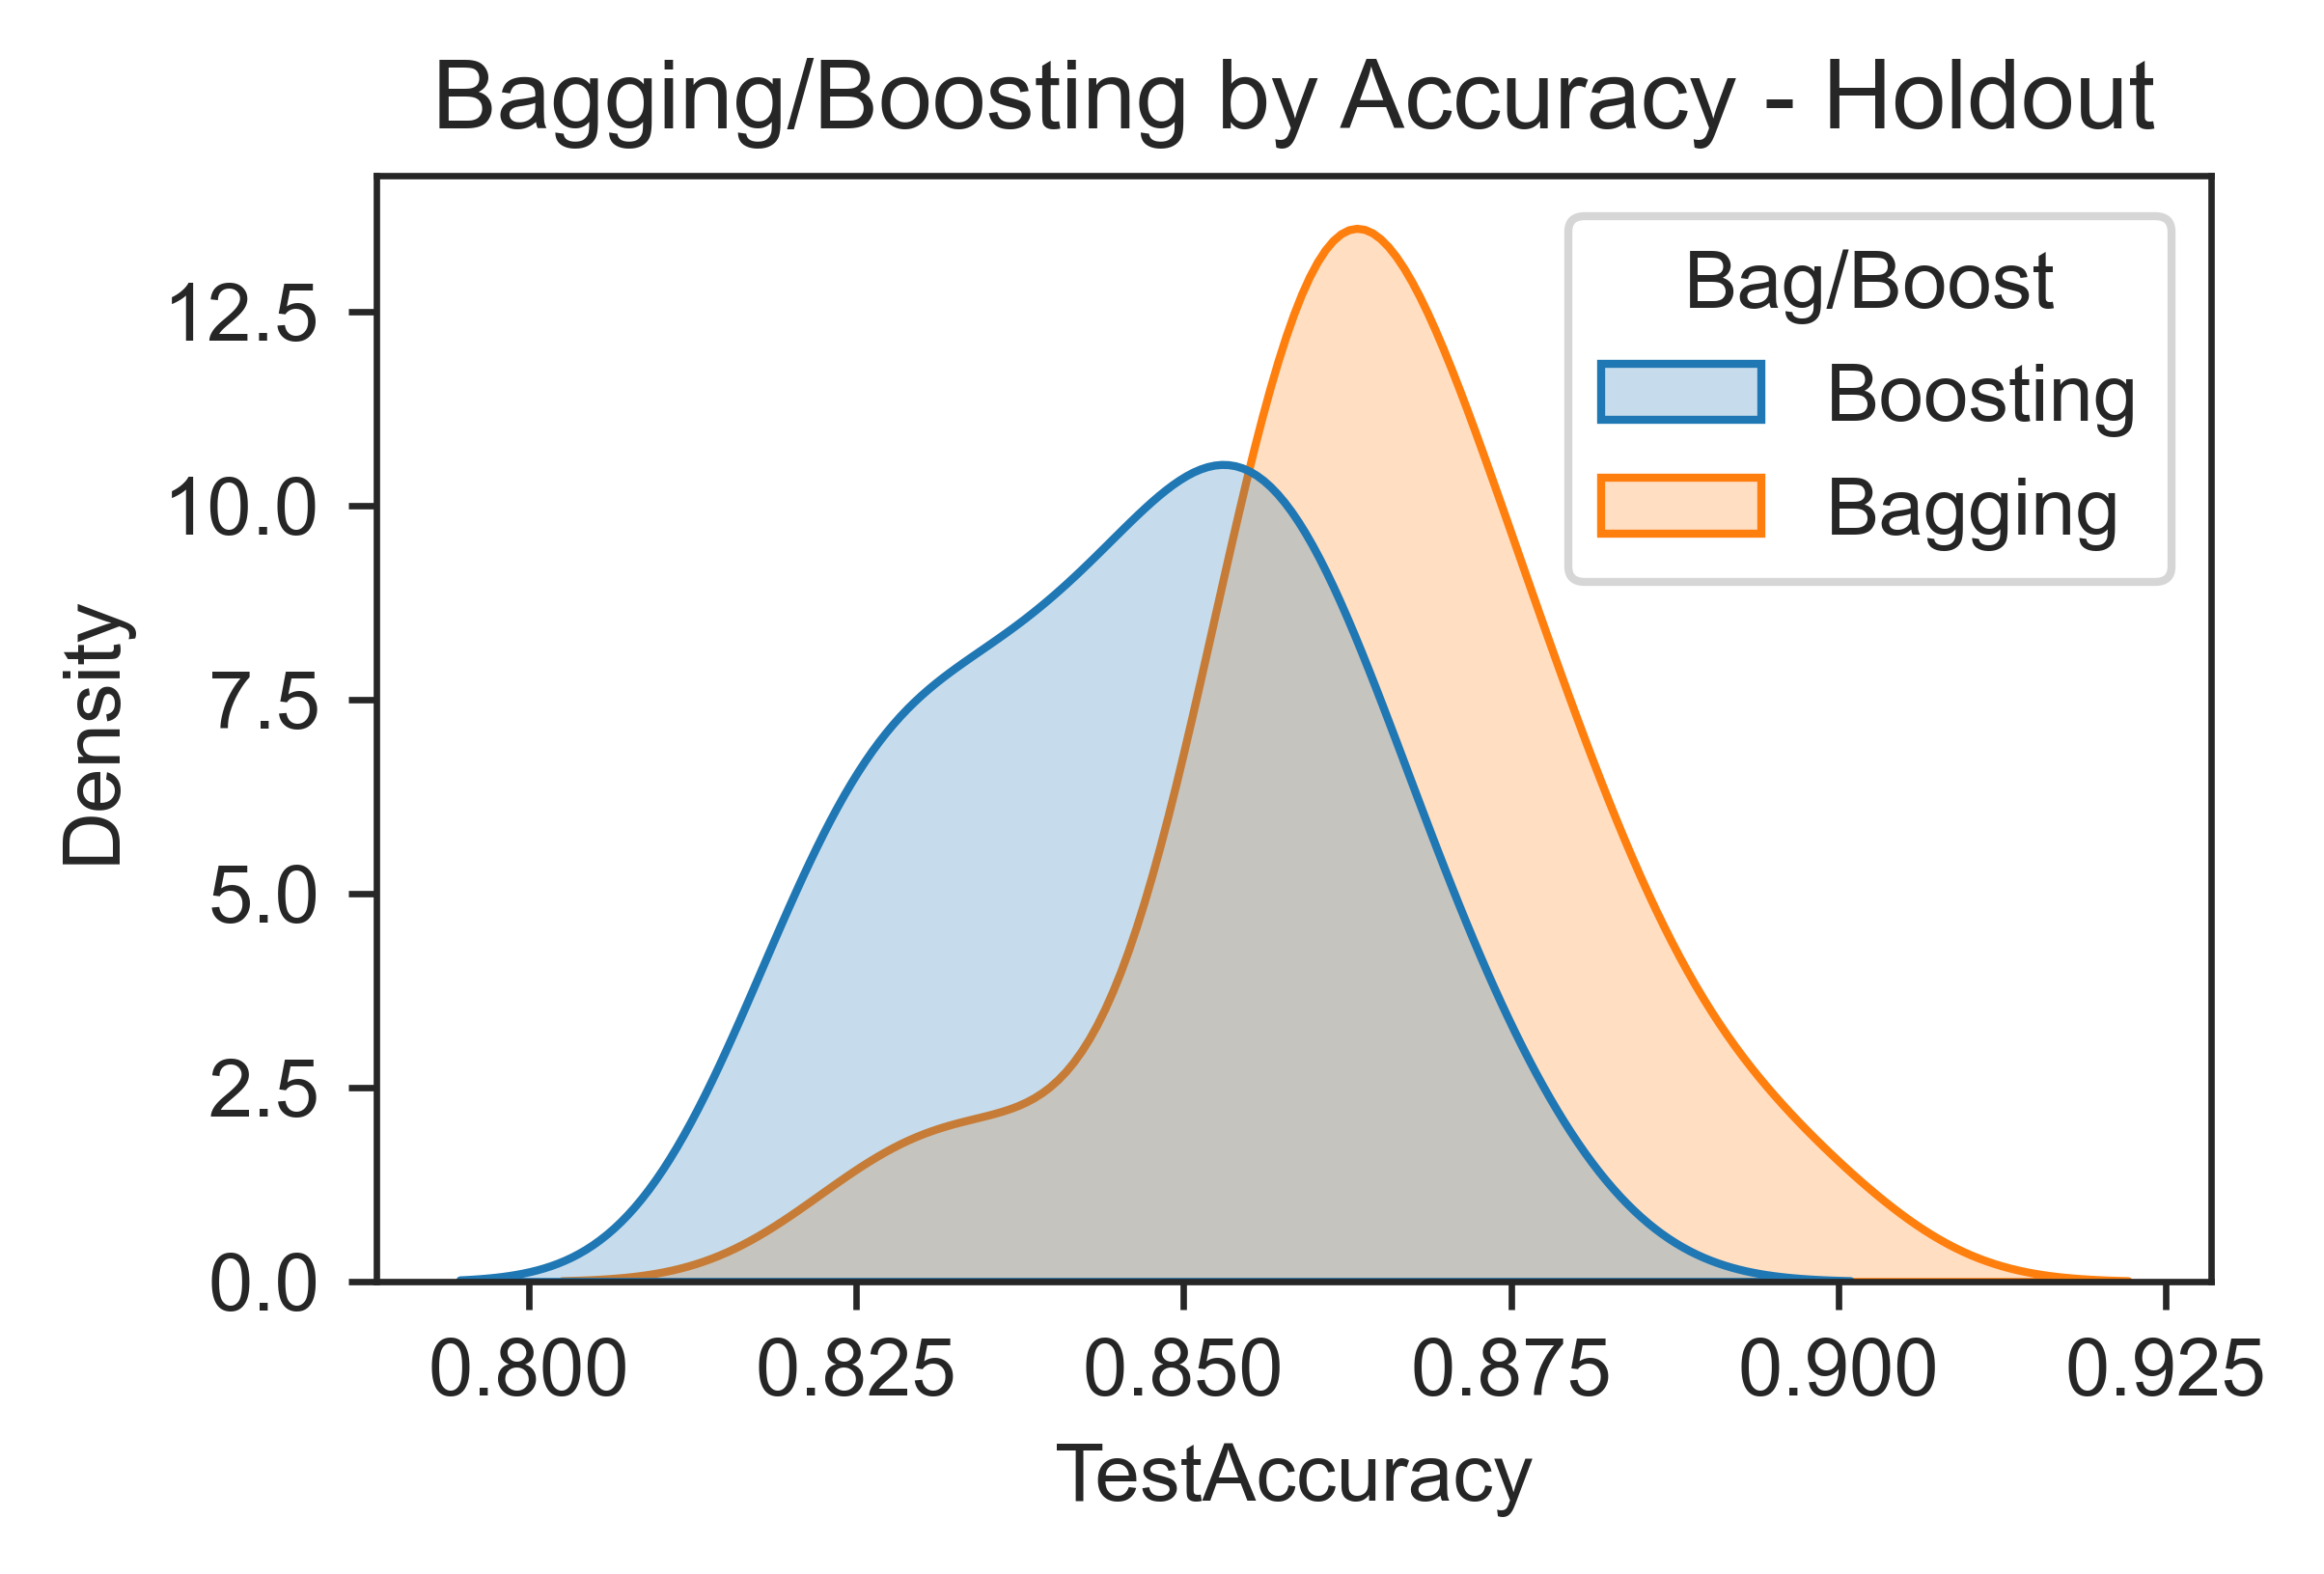

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your metrics and column names as before
target_metrics = ["TestLoss", "TrainLoss", "TestAccuracy", "TrainAccuracy"] 
colnames = ["Loss - Holdout", "Loss - Training", "Accuracy - Holdout", "Accuracy - Training"]

# Set the vertical layout and resolution
# Changed from (2, 2) to (2, 1) and adjusted figsize
fig, axes = plt.subplots(1, 1, figsize=(4, 3), dpi=600)


# --- Plot 2: Validation (Holdout) Accuracy (Bottom) ---
sns.kdeplot(
    data=ep_test[ep_test["Tuning"] == "Tuned"], 
    x=target_metrics[2],  # 'TestAccuracy' (Holdout)
    hue="Bag/Boost", 
    fill=True, 
    ax=axes
)
axes.set_title(f'Bagging/Boosting by {colnames[2]}')

# Adjust layout for title spacing
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.show()

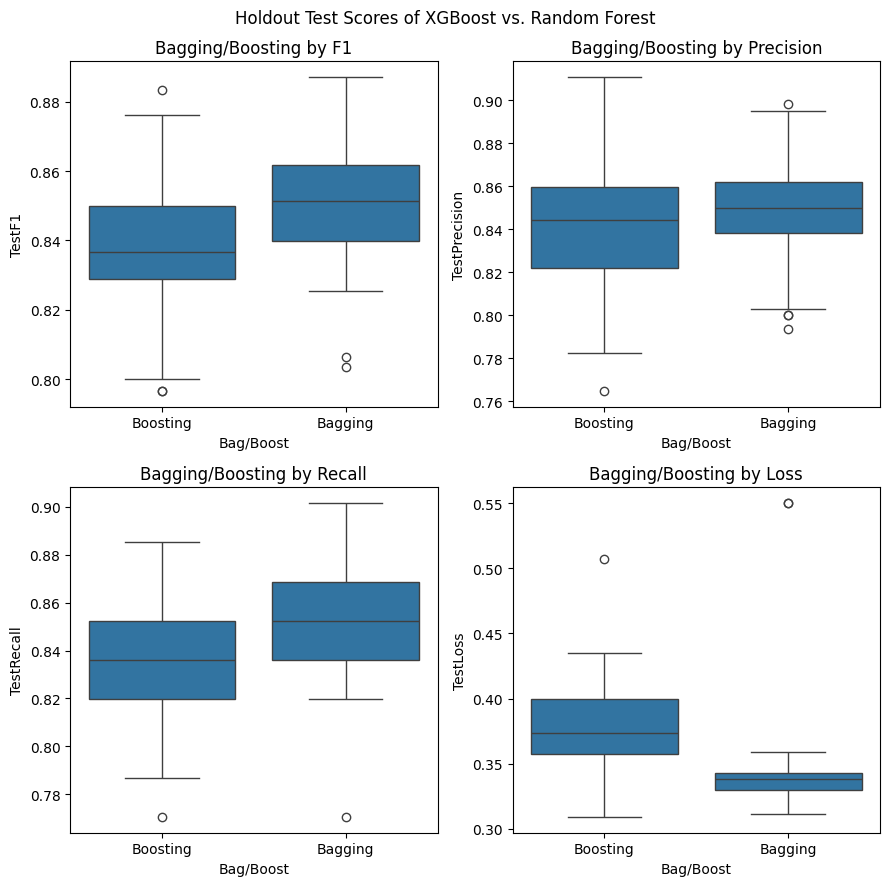

In [48]:
target_metrics = ["TestF1","TestPrecision","TestRecall","TestLoss"] #since classes are balanced no need to look at them seperately
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
fig.suptitle("Holdout Test Scores of XGBoost vs. Random Forest")
axes = axes.flatten()
colnames = ["F1", "Precision", "Recall", "Loss"]
for i, col in enumerate(target_metrics):
    sns.boxplot(data=ep_test, y=col, x="Bag/Boost", ax=axes[i])
    axes[i].set_title(f'Bagging/Boosting by {colnames[i]}')
plt.tight_layout()
plt.show()

# Feedforward Neural Network

# FNN Tuning

#### Building Function

In [51]:
def mbuilder(meta, numlayer = 1, numnodes = 16, numnodes_in = 16, batchnorm = "yes", dropout = "yes", dropout_val_in = 0.2, dropout_val_h = 0.5, activations = "relu", optimizer = "adam"): #no need of smote here. 
    model = Sequential()

    model.add(Input(shape=(meta["n_features_in_"],))) #chatgpt

    model.add(Dense(numnodes_in, activation=activations))

    if dropout == "yes":
        model.add(Dropout(dropout_val_in))

    for i in range(numlayer): 
        model.add(Dense(numnodes, activation=activations))
        if batchnorm == "yes": 
            model.add(BatchNormalization())
        if dropout == "yes": 
            model.add(Dropout(dropout_val_h))
    
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
    optimizer=optimizer, 
    loss="binary_crossentropy", 
    metrics=[
        'accuracy',
        AUC(name='auc'),
        Recall(name='recall'),
        Precision(name='precision')        
    ]
    )

    print(f"||oo|| Training: Layers={numlayer}, Depth={numnodes}, Dropout={[dropout_val_in, dropout_val_h]} ||oo||")
    print("="*65)

    return model


#### Tuning

In [52]:
class SearchHistorySaver(Callback): #chatgpt prompt: <how can i pull the keras history per model> input: mbuilder function and randomsearch. 
    histories = []
    fit_counter = 0

    def on_train_begin(self, logs=None):
        self.epoch_rows = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        row = {"epoch": epoch + 1}

        for key, value in logs.items():
            try:
                row[key] = float(value)
            except Exception:
                row[key] = value

        self.epoch_rows.append(row)

    def on_train_end(self, logs=None):
        hist_df = pd.DataFrame(self.epoch_rows)
        hist_df.insert(0, "fit_id", SearchHistorySaver.fit_counter)

        SearchHistorySaver.histories.append(hist_df)
        SearchHistorySaver.fit_counter += 1 #chatgpt ends.

In [53]:
tf.keras.utils.set_random_seed(SEED)

early_stop = EarlyStopping(
monitor='val_loss', 
patience=20, 
restore_best_weights=True 
)

history_saver = SearchHistorySaver()

cv_nn = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

modelnn = KerasClassifier(
    model=mbuilder,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, history_saver],
    verbose=2,
    fit__validation_split=0.2,
    random_state=SEED,
    model__numlayer=1,
    model__numnodes=16,
    model__numnodes_in=64,
    model__batchnorm="yes",
    model__dropout="yes",
    model__dropout_val_in = 0.2,
    model__dropout_val_h = 0.5
)
param_dist = {
    "estimator__model__numlayer": [1, 2, 3],
    "estimator__model__numnodes": [16, 32, 64],
    "estimator__model__dropout_val_in": [0, 0.2],
    "estimator__model__dropout_val_h": [0.3, 0.4, 0.5],
    "estimator__model__batchnorm" : ["yes","no"],
    "estimator__model__dropout" : ["yes", "no"],
    "estimator__model__optimizer" : ["adam", "sgd"],
    "estimator__model__activations" : ["relu","tanh"]

}

preprocessor = ColumnTransformer(
    transformers=[
        ("num", PowerTransformer(standardize=True), continuous_columns) #standardize = True for standardizing automatically
    ], 
    remainder="passthrough"
)

neural_pipeline = Pipeline(steps =
    [
    ("preprocessor", preprocessor),
    ("estimator", modelnn)
    ]
)

nnsearch = RandomizedSearchCV(
    estimator=neural_pipeline, 
    param_distributions=param_dist, 
    cv=cv_nn, 
    scoring="f1",
    n_jobs=1, 
    verbose=1,
    n_iter=50, 
    return_train_score=True,
    refit = True
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
nnsearch.fit(X_train, y_train)

In [55]:
import os
import json
import joblib
import pandas as pd
from datetime import datetime

# Make a folder for this run
save_dir = "saved_nn_run_" + datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs(save_dir, exist_ok=True)

# Best full sklearn pipeline: preprocessor + neural net estimator
best_pipeline = nnsearch.best_estimator_

# SciKeras estimator inside the pipeline
best_nn = best_pipeline.named_steps["estimator"]

# Actual trained Keras model
keras_model = best_nn.model_

# 1. Save the full pipeline
joblib.dump(best_pipeline, f"{save_dir}/best_pipeline.joblib")

# 2. Save only the Keras model
keras_model.save(f"{save_dir}/keras_model.keras")

# 3. Save training history for plots tomorrow
history = best_nn.history_
pd.DataFrame(history).to_csv(f"{save_dir}/training_history.csv", index=False)

# 4. Save GridSearchCV results
pd.DataFrame(nnsearch.cv_results_).to_csv(f"{save_dir}/gridsearch_results.csv", index=False)

# 5. Save best parameters
with open(f"{save_dir}/best_params.json", "w") as f:
    json.dump(nnsearch.best_params_, f, indent=4, default=str)

# 6. Save best score
with open(f"{save_dir}/best_score.txt", "w") as f:
    f.write(str(nnsearch.best_score_))

ep_dict = [{'Model': item['Model'], **item['Metrics']} for item in metrics_all_list]
pd.DataFrame(ep_dict).to_csv(f"{save_dir}/all_model_metrics.csv", index=False)

print(f"Saved everything in: {save_dir}")

Saved everything in: saved_nn_run_20260608_122658


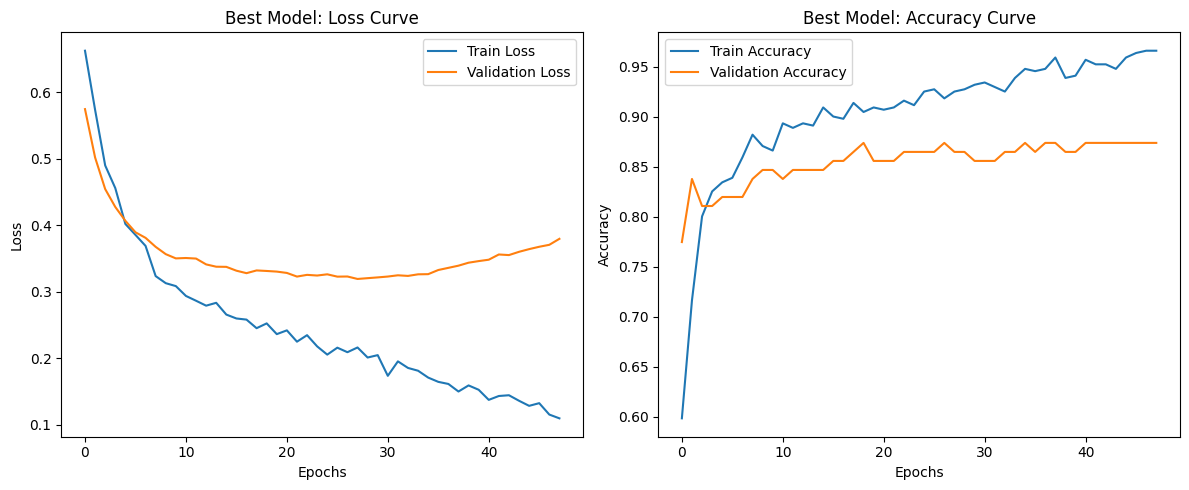

In [56]:
best_nn = nnsearch.best_estimator_.named_steps["estimator"]

# 3. Access the scikeras history_ dictionary
history = best_nn.history_

# 4. Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Best Model: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 5. Plot Accuracy (or any other metric you tracked like 'auc')
plt.subplot(1, 2, 2)
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Best Model: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

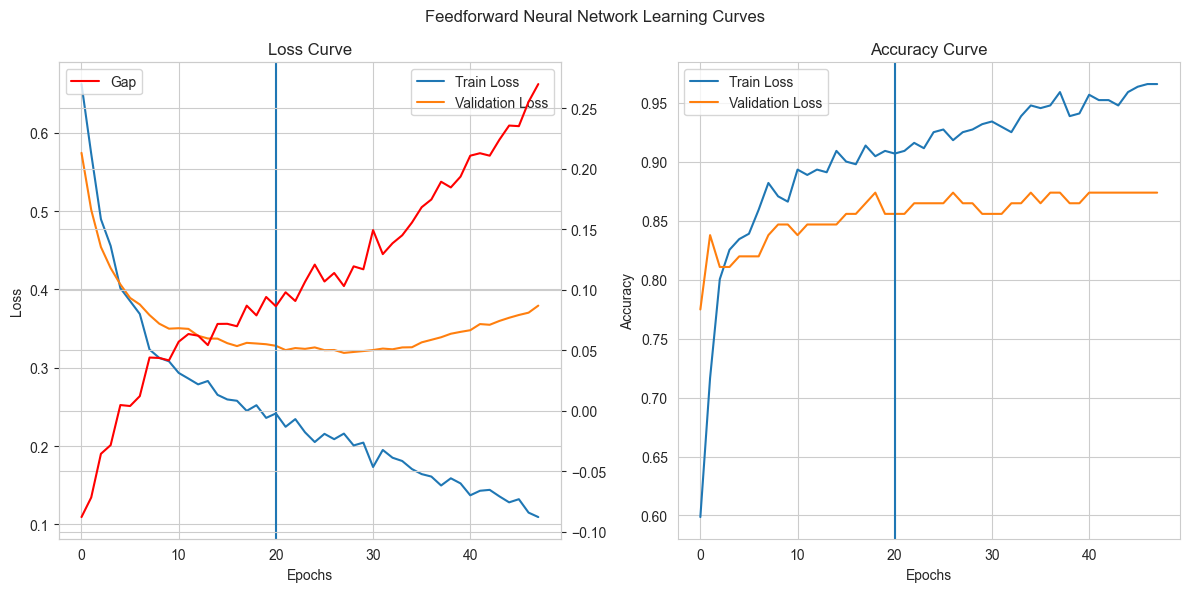

In [57]:
sns.set_style("whitegrid")
best_nn = nnsearch.best_estimator_.named_steps["estimator"]

history = best_nn.history_

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Feedforward Neural Network Learning Curves")

axes = axes.flatten()

ax_l = axes[0].twinx()

sns.lineplot(history['loss'], label='Train Loss', ax=axes[0])
sns.lineplot(history['val_loss'], label='Validation Loss', ax=axes[0])
axes[0].axvline(x=20) # Attached explicitly to the left plot
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
sns.lineplot([v-t for t,v in zip(history["loss"],history["val_loss"])], label="Gap", ax=ax_l, color="red")
ax_l.legend()

sns.lineplot(history['accuracy'], label='Train Loss', ax=axes[1])
sns.lineplot(history['val_accuracy'], label='Validation Loss', ax=axes[1])
axes[1].axvline(x=20) # Attached explicitly to the left plot
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

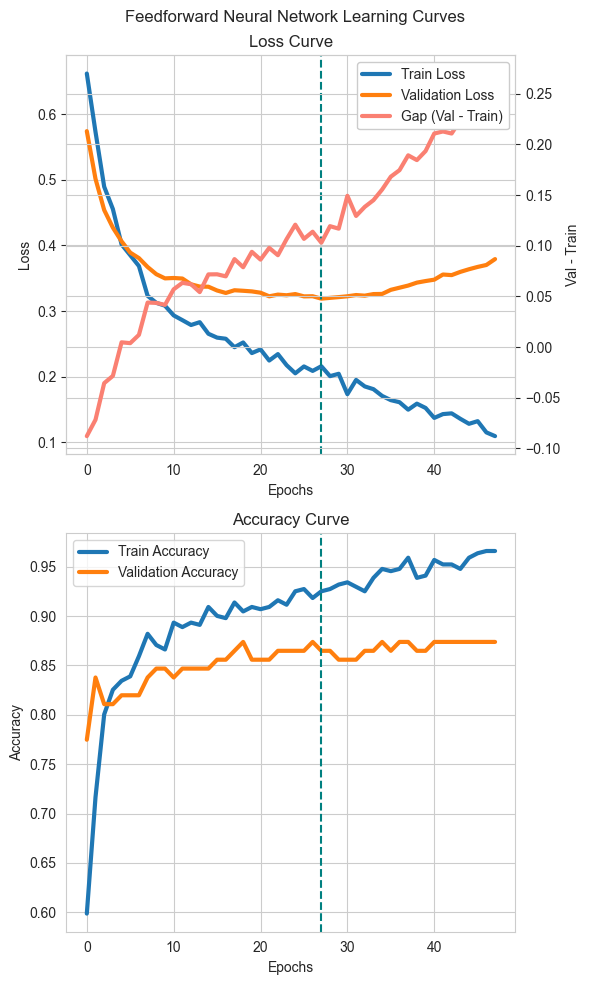

In [58]:
sns.set_style("whitegrid")
best_nn = nnsearch.best_estimator_.named_steps["estimator"]

history = best_nn.history_

fig, axes = plt.subplots(2, 1, figsize=(6, 10))
fig.suptitle("Feedforward Neural Network Learning Curves")

axes = axes.flatten()

ax_l = axes[0].twinx()
sns.lineplot(history['loss'], label='Train Loss', ax=axes[0], linewidth=3)
sns.lineplot(history['val_loss'], label='Validation Loss', ax=axes[0], linewidth=3)
axes[0].axvline(x=27, color='teal', linestyle='--', alpha=1)   
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')

gap = [v - t for t, v in zip(history["loss"], history["val_loss"])]
sns.lineplot(gap, label="Gap (Val - Train)", ax=ax_l, color="salmon", linewidth = 3)
ax_l.set_ylabel("Val - Train")

lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = ax_l.get_legend_handles_labels()
ax_l.legend(
    lines_1 + lines_2, 
    labels_1 + labels_2, 
    loc='upper right', 
    frameon=True,       
    facecolor='white', 
    framealpha=1        
)
if axes[0].get_legend():
    axes[0].get_legend().remove()


# Right plot: Accuracy
sns.lineplot(history['accuracy'], label='Train Accuracy', ax=axes[1], linewidth = 3)      # <-- fixed label
sns.lineplot(history['val_accuracy'], label='Validation Accuracy', ax=axes[1], linewidth = 3)  # <-- fixed label
axes[1].axvline(x=27, color='teal', linestyle='--', alpha=1)   # <-- changed to axvline
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

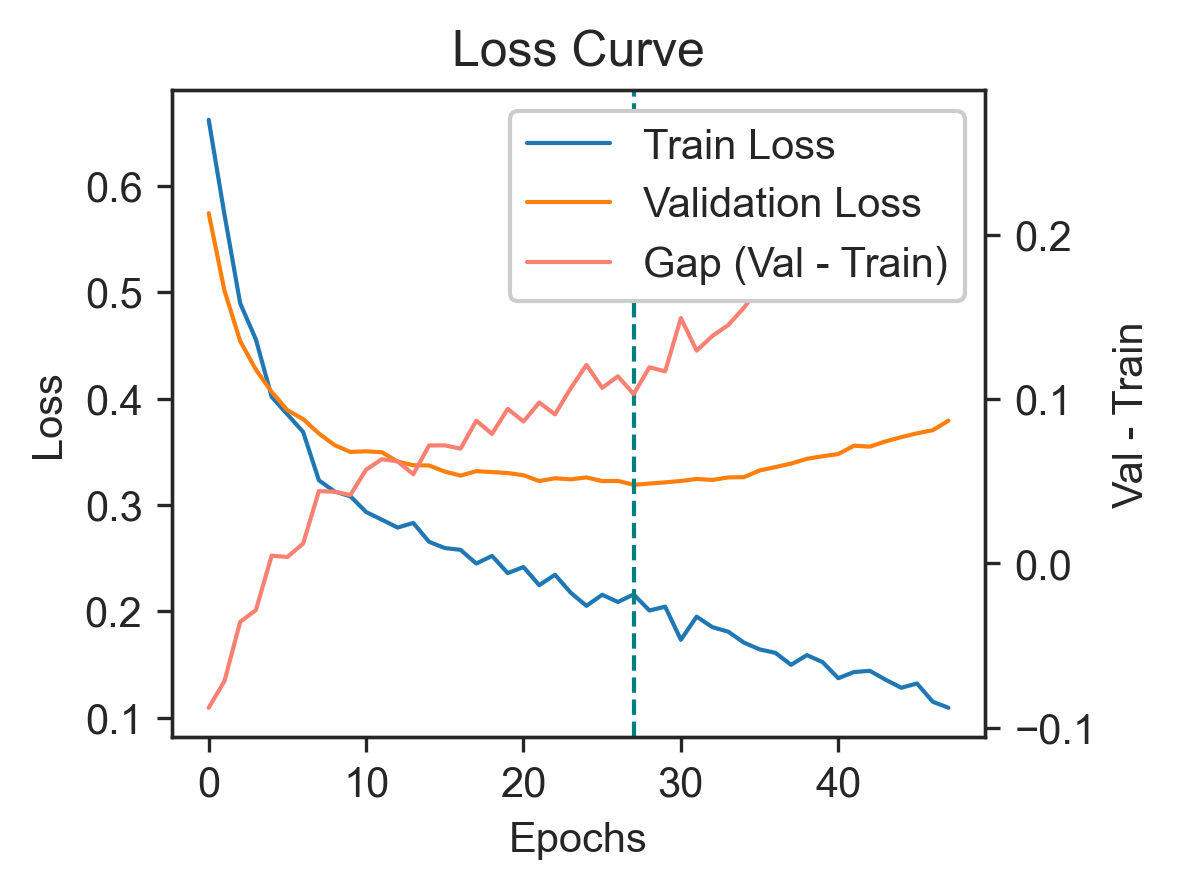

In [59]:

sns.set_style("ticks")
fig, axes = plt.subplots(figsize=(3.5, 2.8), dpi=300)
ax_l = axes.twinx()
sns.lineplot(history['loss'], label='Train Loss', ax=axes, linewidth=1)
sns.lineplot(history['val_loss'], label='Validation Loss', ax=axes, linewidth=1)
axes.axvline(x=27, color='teal', linestyle='--', alpha=1, linewidth=1)   
axes.set_title('Loss Curve')
axes.set_xlabel('Epochs')
axes.set_ylabel('Loss')

gap = [v - t for t, v in zip(history["loss"], history["val_loss"])]
sns.lineplot(gap, label="Gap (Val - Train)", ax=ax_l, color="salmon", linewidth = 1)
ax_l.set_ylabel("Val - Train")

lines_1, labels_1 = axes.get_legend_handles_labels()
lines_2, labels_2 = ax_l.get_legend_handles_labels()
ax_l.legend(
    lines_1 + lines_2, 
    labels_1 + labels_2, 
    loc='upper right', 
    frameon=True,       
    facecolor='white', 
    framealpha=1        
)
if axes.get_legend():
    axes.get_legend().remove()
plt.show()

In [60]:
fetch_metrics_to_list(X_train, X_test, y_train, y_test, best_pipeline, "Network")

18/18 - 0s - 5ms/step
5/5 - 0s - 7ms/step
18/18 - 0s - 2ms/step
5/5 - 0s - 7ms/step


{'Model': 'Network',
 'Metrics': {'TestAccuracy': 0.8405797101449275,
  'TrainAccuracy': 0.9148550724637681,
  'TestPrecision': 0.8305084745762712,
  'TrainPrecision': 0.902834008097166,
  'TestRecall': 0.8032786885245902,
  'TrainRecall': 0.9065040650406504,
  'TestF1': 0.8166666666666667,
  'TrainF1': 0.9046653144016227,
  'TestLoss': 0.36947968431083783,
  'TrainLoss': 0.2125939094620265,
  'TestROC_AUC': 0.8367042793272301,
  'TrainROC_AUC': 0.9140363462458155}}

# Final Scores

In [61]:
A8Predictions = df["A8"][y_test.index] 


In [62]:
y_test

566    1
338    1
126    1
587    1
556    0
      ..
283    0
11     1
187    0
167    1
80     1
Name: T, Length: 138, dtype: int64

In [63]:
A8Predictions = A8Predictions.astype(int)

In [64]:

A8_Accuracy = accuracy_score(y_test, A8Predictions)
A8_F1Sc  = f1_score(y_test, A8Predictions)
A8_Roc_Auc = roc_auc_score(y_test, A8Predictions)
A8_Recall = recall_score(y_test, A8Predictions)
A8_Precision = precision_score(y_test, A8Predictions)
a8_dct = {"Model": "Feature A8", 
            "Metrics": {"TestAccuracy": A8_Accuracy, "TrainAccuracy": None,
            "TestPrecision": A8_Precision, "TrainPrecision": None, 
            "TestRecall": A8_Recall, "TrainRecall": None,
            "TestF1": A8_F1Sc, "TrainF1": None, "TestLoss": None,"TrainLoss": None,
            "TestROC_AUC": A8_Roc_Auc, "TrainROC_AUC": None}
            }
metrics_all_list.append(a8_dct)

In [65]:
final_scores = [{'Model': item['Model'], **item['Metrics']} for item in metrics_all_list]
final_scores = pd.DataFrame(final_scores)
final_scores.head()

,Model,TestAccuracy,TrainAccuracy,TestPrecision,TrainPrecision,TestRecall,TrainRecall,TestF1,TrainF1,TestLoss,TrainLoss,TestROC_AUC,TrainROC_AUC
0,K-Neighbors,0.855072,1.000000,0.859649,1.000000,0.803279,1.000000,0.830508,1.000000,1.066900,2.220446e-16,0.849691,1.000000
1,Naive Bayes,0.840580,0.880435,0.830508,0.862903,0.803279,0.869919,0.816667,0.866397,0.681502,6.313348e-01,0.836704,0.879404
2,SVM,0.869565,0.947464,0.905660,0.946502,0.786885,0.934959,0.842105,0.940695,NaN,NaN,0.860975,0.946238
3,Polynomial SVM,0.884393,0.945841,0.913043,0.942982,0.818182,0.934783,0.863014,0.938865,NaN,NaN,0.877841,0.944743
4,Linear SVM,0.820809,0.862669,0.896552,0.907692,0.675325,0.769565,0.770370,0.832941,NaN,NaN,0.806412,0.853424


In [66]:
final_scores

,Model,TestAccuracy,TrainAccuracy,TestPrecision,TrainPrecision,TestRecall,TrainRecall,TestF1,TrainF1,TestLoss,TrainLoss,TestROC_AUC,TrainROC_AUC
0,K-Neighbors,0.855072,1.000000,0.859649,1.000000,0.803279,1.000000,0.830508,1.000000,1.066900,2.220446e-16,0.849691,1.000000
1,Naive Bayes,0.840580,0.880435,0.830508,0.862903,0.803279,0.869919,0.816667,0.866397,0.681502,6.313348e-01,0.836704,0.879404
2,SVM,0.869565,0.947464,0.905660,0.946502,0.786885,0.934959,0.842105,0.940695,NaN,NaN,0.860975,0.946238
3,Polynomial SVM,0.884393,0.945841,0.913043,0.942982,0.818182,0.934783,0.863014,0.938865,NaN,NaN,0.877841,0.944743
4,Linear SVM,0.820809,0.862669,0.896552,0.907692,0.675325,0.769565,0.770370,0.832941,NaN,NaN,0.806412,0.853424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
244,__TEST_Baseline_XGB_30,0.869565,0.951087,0.905660,0.950617,0.786885,0.939024,0.842105,0.944785,0.434360,1.508095e-01,0.860975,0.949904
245,__TEST_Tuned_RF_30,0.898551,0.918478,0.898305,0.910204,0.868852,0.906504,0.883333,0.908350,0.332695,2.452133e-01,0.895465,0.917304
246,__TEST_Baseline_RF_30,0.891304,0.967391,0.883333,0.971074,0.868852,0.955285,0.876033,0.963115,0.341671,2.701534e-01,0.888972,0.966204
247,Network,0.840580,0.914855,0.830508,0.902834,0.803279,0.906504,0.816667,0.904665,0.369480,2.125939e-01,0.836704,0.914036


In [67]:
final_scores.to_csv("final_scores_ppj.csv")

In [68]:
final_scores=final_scores.drop([j+6 for j in range(241)], axis=0)


In [69]:
final_scores = final_scores.drop([2], axis=0)

In [70]:
final_scores

,Model,TestAccuracy,TrainAccuracy,TestPrecision,TrainPrecision,TestRecall,TrainRecall,TestF1,TrainF1,TestLoss,TrainLoss,TestROC_AUC,TrainROC_AUC
0,K-Neighbors,0.855072,1.000000,0.859649,1.000000,0.803279,1.000000,0.830508,1.000000,1.066900,2.220446e-16,0.849691,1.000000
1,Naive Bayes,0.840580,0.880435,0.830508,0.862903,0.803279,0.869919,0.816667,0.866397,0.681502,6.313348e-01,0.836704,0.879404
3,Polynomial SVM,0.884393,0.945841,0.913043,0.942982,0.818182,0.934783,0.863014,0.938865,NaN,NaN,0.877841,0.944743
4,Linear SVM,0.820809,0.862669,0.896552,0.907692,0.675325,0.769565,0.770370,0.832941,NaN,NaN,0.806412,0.853424
5,RandomForest,0.869565,0.940217,0.864407,0.938272,0.836066,0.926829,0.850000,0.932515,0.334944,2.091162e-01,0.866085,0.938905
247,Network,0.840580,0.914855,0.830508,0.902834,0.803279,0.906504,0.816667,0.904665,0.369480,2.125939e-01,0.836704,0.914036
248,Feature A8,0.840580,NaN,0.767123,NaN,0.918033,NaN,0.835821,NaN,NaN,NaN,0.848627,NaN


In [71]:
cv_res_svm = pd.DataFrame(svm_gs.cv_results_)

In [72]:
cv_res_rf = pd.DataFrame(cv_res_rf)
